In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/home-data-for-ml-course/train.csv
/kaggle/input/home-data-for-ml-course/train.csv.gz
/kaggle/input/home-data-for-ml-course/sample_submission.csv.gz
/kaggle/input/home-data-for-ml-course/test.csv.gz
/kaggle/input/home-data-for-ml-course/test.csv
/kaggle/input/home-data-for-ml-course/sample_submission.csv
/kaggle/input/home-data-for-ml-course/data_description.txt


In [2]:
train = pd.read_csv('/kaggle/input/home-data-for-ml-course/train.csv')
test = pd.read_csv('/kaggle/input/home-data-for-ml-course/test.csv')
sub = pd.read_csv('/kaggle/input/home-data-for-ml-course/sample_submission.csv')


In [3]:
sub.head(20)

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977
5,1466,177150.989247
6,1467,172070.659229
7,1468,175110.956520
8,1469,162011.698832
9,1470,160726.247831


In [4]:
train.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# We will deal with one column at a time

**Lets us combine our train and test dataset**

In [6]:
data = pd.concat([train,test], axis=0, ignore_index=True)

In [7]:
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
2915,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
2916,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
2917,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN


In [8]:
data['MSSubClass'].nunique()

16

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

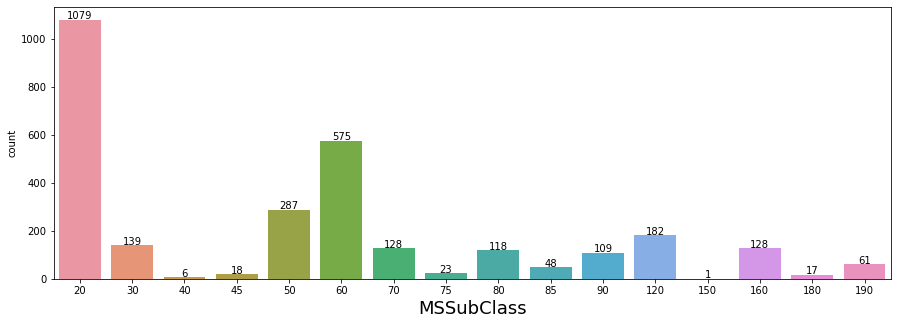

In [10]:

plt.figure(figsize=(15,5))

ax =  sns.countplot(x='MSSubClass', data = data)
ax.set_xlabel('MSSubClass', fontsize=18)
for p in ax.patches:
    height = p.get_height()
    width = p.get_width()/2
    ax.text(p.get_x()+width,height + 3,
           '{:1}'.format(height),
           ha = "center")
    
plt.show()

# lets map these value using label encoder

In [11]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
data['MSSubClass'] = le.fit_transform(data['MSSubClass'])


In [12]:
data[['MSSubClass']].head()

,MSSubClass
0,5
1,0
2,5
3,6
4,5


In [13]:
data['MSZoning'].nunique()

5

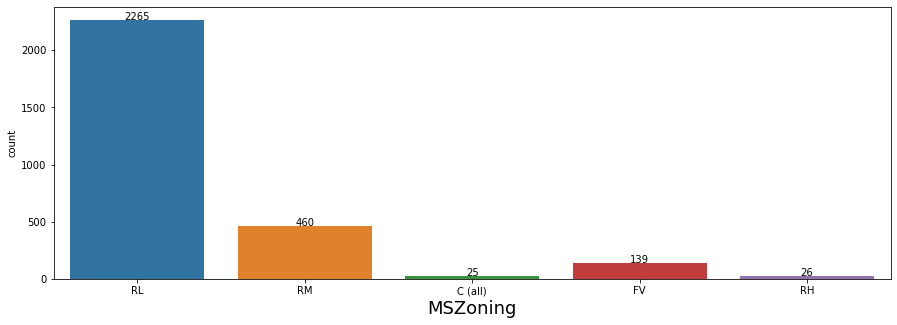

In [14]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['MSZoning'])
ax.set_xlabel('MSZoning', fontsize=18)
for p in ax.patches:
    height = p.get_height()
    width = p.get_width()/2
    ax.text(p.get_x()+width,height + 3,
           '{:1}'.format(height),
           ha = "center")
    
plt.show()




**Lets create dummy classes for this column**

In [15]:
dum = pd.get_dummies(data['MSZoning'],prefix='MSZoning')
data = pd.concat([data,dum], axis=1)
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM
0,1,5,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,2,2008,WD,Normal,208500.0,0,0,0,1,0
1,2,0,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,5,2007,WD,Normal,181500.0,0,0,0,1,0
2,3,5,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,9,2008,WD,Normal,223500.0,0,0,0,1,0
3,4,6,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,2,2006,WD,Abnorml,140000.0,0,0,0,1,0
4,5,5,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,12,2008,WD,Normal,250000.0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,13,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,6,2006,WD,Normal,NaN,0,0,0,0,1
2915,2916,13,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,4,2006,WD,Abnorml,NaN,0,0,0,0,1
2916,2917,0,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,9,2006,WD,Abnorml,NaN,0,0,0,1,0
2917,2918,9,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,7,2006,WD,Normal,NaN,0,0,0,1,0


In [16]:
data.drop(columns=['MSZoning'], inplace=True)


**Second column**

In [17]:
data['LotFrontage'].nunique()

128

In [18]:
data['LotFrontage'].isnull().sum()

# it has 486 null values

486

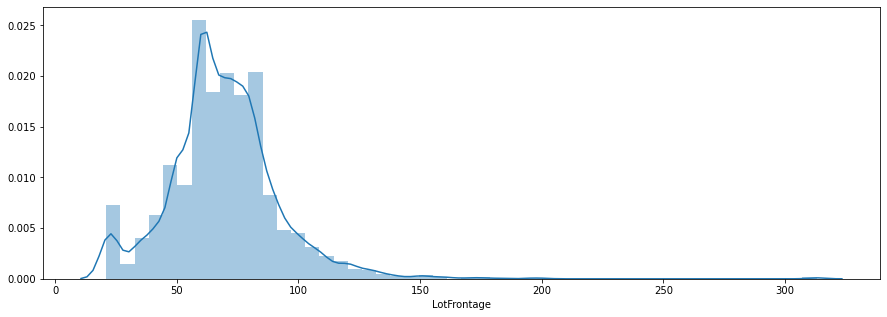

In [19]:
plt.figure(figsize=(15,5))
sns.distplot(data['LotFrontage'])

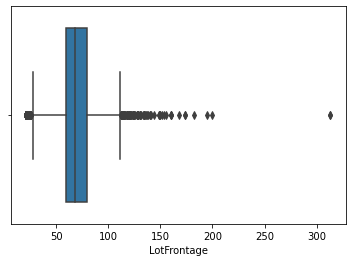

In [20]:
sns.boxplot(data['LotFrontage'])

In [21]:
from sklearn.impute import KNNImputer
imputer = KNNImputer( n_neighbors=10, metric='nan_euclidean',weights='uniform')
x = imputer.fit_transform(data[['LotFrontage']]) 
Xtrans = imputer.transform(x)
data['LotFrontage'] = Xtrans
data.head(10)

,Id,MSSubClass,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM
0,1,5,65.000000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,2,2008,WD,Normal,208500.0,0,0,0,1,0
1,2,0,80.000000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,5,2007,WD,Normal,181500.0,0,0,0,1,0
2,3,5,68.000000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,9,2008,WD,Normal,223500.0,0,0,0,1,0
3,4,6,60.000000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,2,2006,WD,Abnorml,140000.0,0,0,0,1,0
4,5,5,84.000000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,12,2008,WD,Normal,250000.0,0,0,0,1,0
5,6,4,85.000000,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,...,10,2009,WD,Normal,143000.0,0,0,0,1,0
6,7,0,75.000000,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,...,8,2007,WD,Normal,307000.0,0,0,0,1,0
7,8,5,69.305795,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,...,11,2009,WD,Normal,200000.0,0,0,0,1,0
8,9,4,51.000000,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,...,4,2008,WD,Abnorml,129900.0,0,0,0,0,1
9,10,15,50.000000,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,...,1,2008,WD,Normal,118000.0,0,0,0,1,0


In [22]:
  
from scipy.stats import skew 
print('\nSkewness for data : ', skew(data['LotFrontage'])) 



Skewness for data :  1.6455737855221888


**Removing outlier**

In [23]:
# i = data['LotFrontage'].quantile(.98)
# data = data[data['LotFrontage']<i]

1.6455737855221888

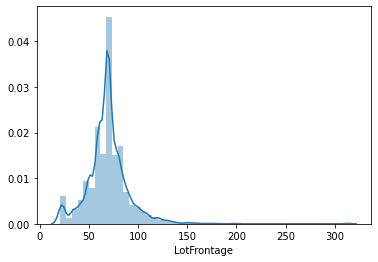

In [24]:
p = data['LotFrontage']
sns.distplot(p)
skew(p)

**Third column**

In [25]:
data['LotArea'].nunique()

1951

In [26]:
data['LotArea'].isnull().sum()

0

12.822431401556724

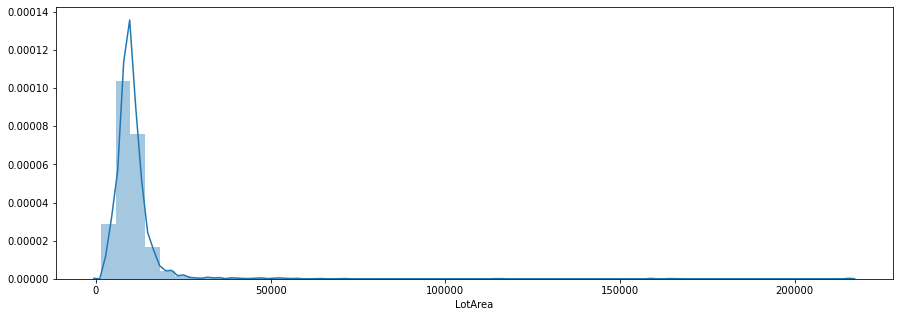

In [27]:
plt.figure(figsize=(15,5))

sns.distplot(data['LotArea'])
skew(data['LotArea'])

****Data is highly skewed****

In [28]:
data['LotArea'] = np.log1p(data['LotArea'])



-0.50475055129892


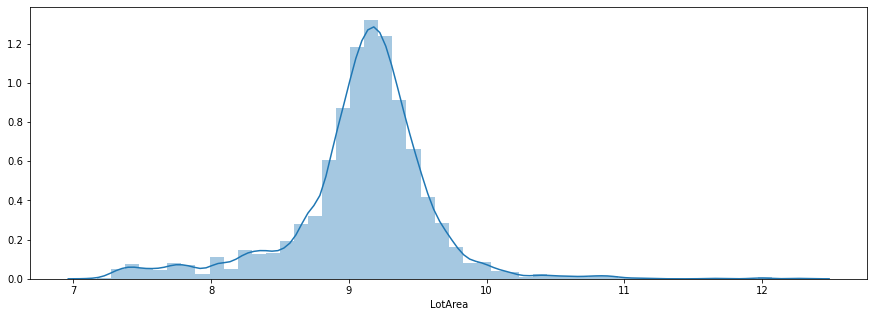

In [29]:
print(skew(data['LotArea']))
plt.figure(figsize=(15,5))

sns.distplot(data['LotArea'])

In [30]:
data

,Id,MSSubClass,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM
0,1,5,65.0,9.042040,Pave,NaN,Reg,Lvl,AllPub,Inside,...,2,2008,WD,Normal,208500.0,0,0,0,1,0
1,2,0,80.0,9.169623,Pave,NaN,Reg,Lvl,AllPub,FR2,...,5,2007,WD,Normal,181500.0,0,0,0,1,0
2,3,5,68.0,9.328212,Pave,NaN,IR1,Lvl,AllPub,Inside,...,9,2008,WD,Normal,223500.0,0,0,0,1,0
3,4,6,60.0,9.164401,Pave,NaN,IR1,Lvl,AllPub,Corner,...,2,2006,WD,Abnorml,140000.0,0,0,0,1,0
4,5,5,84.0,9.565284,Pave,NaN,IR1,Lvl,AllPub,FR2,...,12,2008,WD,Normal,250000.0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,13,21.0,7.568896,Pave,NaN,Reg,Lvl,AllPub,Inside,...,6,2006,WD,Normal,NaN,0,0,0,0,1
2915,2916,13,21.0,7.546974,Pave,NaN,Reg,Lvl,AllPub,Inside,...,4,2006,WD,Abnorml,NaN,0,0,0,0,1
2916,2917,0,160.0,9.903538,Pave,NaN,Reg,Lvl,AllPub,Inside,...,9,2006,WD,Abnorml,NaN,0,0,0,1,0
2917,2918,9,62.0,9.253591,Pave,NaN,Reg,Lvl,AllPub,Inside,...,7,2006,WD,Normal,NaN,0,0,0,1,0


***Street column***

In [31]:
data['Street'].nunique()

2

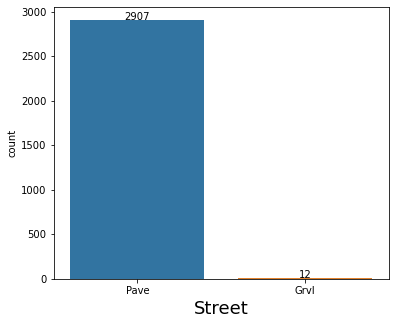

In [32]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data['Street'])

ax.set_xlabel('Street', fontsize=18)
for p in ax.patches:
    height = p.get_height()
    width = p.get_width()/2
    ax.text(p.get_x()+width,height + 3,
           '{:1}'.format(height),
           ha = "center")
    
plt.show()

In [33]:
dum = pd.get_dummies(data['Street'], prefix='Street')

data = pd.concat([data,dum], axis=1)

In [34]:
data.drop(columns='Street', inplace=True)
data

,Id,MSSubClass,LotFrontage,LotArea,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,SaleType,SaleCondition,SalePrice,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave
0,1,5,65.0,9.042040,NaN,Reg,Lvl,AllPub,Inside,Gtl,...,WD,Normal,208500.0,0,0,0,1,0,0,1
1,2,0,80.0,9.169623,NaN,Reg,Lvl,AllPub,FR2,Gtl,...,WD,Normal,181500.0,0,0,0,1,0,0,1
2,3,5,68.0,9.328212,NaN,IR1,Lvl,AllPub,Inside,Gtl,...,WD,Normal,223500.0,0,0,0,1,0,0,1
3,4,6,60.0,9.164401,NaN,IR1,Lvl,AllPub,Corner,Gtl,...,WD,Abnorml,140000.0,0,0,0,1,0,0,1
4,5,5,84.0,9.565284,NaN,IR1,Lvl,AllPub,FR2,Gtl,...,WD,Normal,250000.0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,13,21.0,7.568896,NaN,Reg,Lvl,AllPub,Inside,Gtl,...,WD,Normal,NaN,0,0,0,0,1,0,1
2915,2916,13,21.0,7.546974,NaN,Reg,Lvl,AllPub,Inside,Gtl,...,WD,Abnorml,NaN,0,0,0,0,1,0,1
2916,2917,0,160.0,9.903538,NaN,Reg,Lvl,AllPub,Inside,Gtl,...,WD,Abnorml,NaN,0,0,0,1,0,0,1
2917,2918,9,62.0,9.253591,NaN,Reg,Lvl,AllPub,Inside,Gtl,...,WD,Normal,NaN,0,0,0,1,0,0,1


**Alley column**

In [35]:
data['Alley'].isnull().sum()

2721

**As it contain many null values, so we will drop this column**

In [36]:
data.drop(columns='Alley', inplace=True)

**LotShape column**

In [37]:
data['LotShape'].nunique()

4

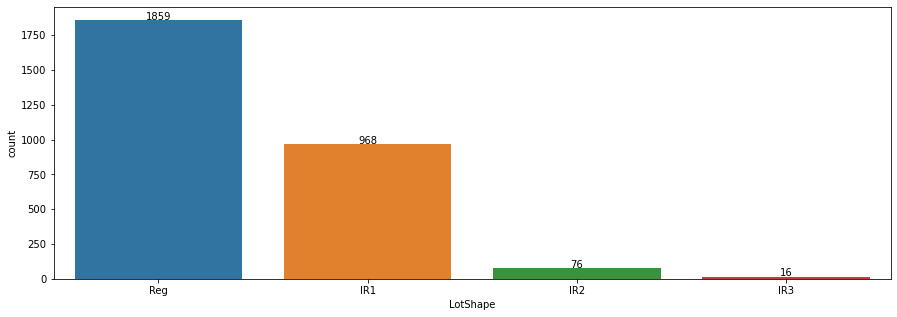

In [38]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['LotShape'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()   
    

In [39]:
dum = pd.get_dummies(data['LotShape'], prefix='LotShape')
data = pd.concat([data,dum], axis=1)

In [40]:
data.drop(columns='LotShape', inplace=True)
data

,Id,MSSubClass,LotFrontage,LotArea,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg
0,1,5,65.0,9.042040,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,0,0,1,0,0,1,0,0,0,1
1,2,0,80.0,9.169623,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,0,0,1,0,0,1,0,0,0,1
2,3,5,68.0,9.328212,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,0,0,1,0,0,1,1,0,0,0
3,4,6,60.0,9.164401,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,0,0,1,0,0,1,1,0,0,0
4,5,5,84.0,9.565284,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,0,0,1,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,13,21.0,7.568896,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,...,0,0,0,1,0,1,0,0,0,1
2915,2916,13,21.0,7.546974,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,...,0,0,0,1,0,1,0,0,0,1
2916,2917,0,160.0,9.903538,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,...,0,0,1,0,0,1,0,0,0,1
2917,2918,9,62.0,9.253591,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,...,0,0,1,0,0,1,0,0,0,1


**LandContour column**

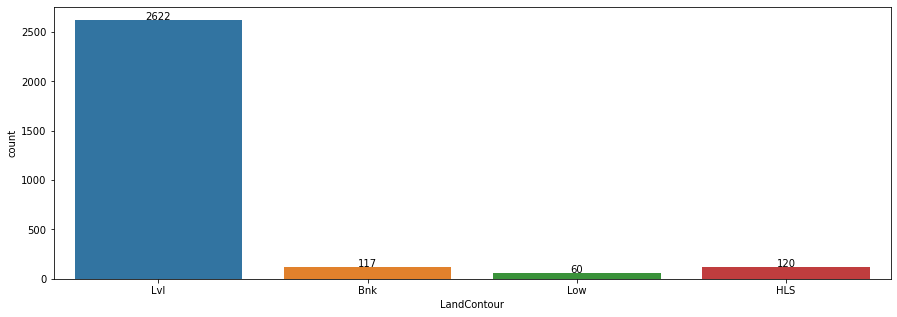

In [41]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['LandContour'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()   
    

In [42]:
dum = pd.get_dummies(data['LandContour'], prefix='LandContour')
dum
data = pd.concat([data,dum], axis=1)

In [43]:
data.drop(columns='LandContour', inplace=True)
data

,Id,MSSubClass,LotFrontage,LotArea,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl
0,1,5,65.0,9.042040,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,0,1,0,0,0,1,0,0,0,1
1,2,0,80.0,9.169623,AllPub,FR2,Gtl,Veenker,Feedr,Norm,...,0,1,0,0,0,1,0,0,0,1
2,3,5,68.0,9.328212,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,0,1,1,0,0,0,0,0,0,1
3,4,6,60.0,9.164401,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,0,1,1,0,0,0,0,0,0,1
4,5,5,84.0,9.565284,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,0,1,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,13,21.0,7.568896,AllPub,Inside,Gtl,MeadowV,Norm,Norm,...,0,1,0,0,0,1,0,0,0,1
2915,2916,13,21.0,7.546974,AllPub,Inside,Gtl,MeadowV,Norm,Norm,...,0,1,0,0,0,1,0,0,0,1
2916,2917,0,160.0,9.903538,AllPub,Inside,Gtl,Mitchel,Norm,Norm,...,0,1,0,0,0,1,0,0,0,1
2917,2918,9,62.0,9.253591,AllPub,Inside,Gtl,Mitchel,Norm,Norm,...,0,1,0,0,0,1,0,0,0,1


***Utilities column***

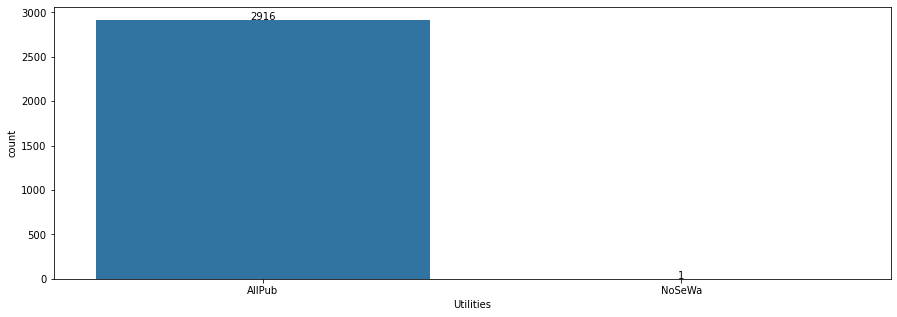

In [44]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['Utilities'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()   
    

In [45]:
data['Utilities'].isnull().sum()

2

In [46]:
data['Utilities'].fillna('AllPub', inplace=True)

**here we will do label encoding instead of one hot encoding**

In [47]:
le = preprocessing.LabelEncoder()
data['Utilities'] = le.fit_transform(data['Utilities'])
data

,Id,MSSubClass,LotFrontage,LotArea,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl
0,1,5,65.0,9.042040,0,Inside,Gtl,CollgCr,Norm,Norm,...,0,1,0,0,0,1,0,0,0,1
1,2,0,80.0,9.169623,0,FR2,Gtl,Veenker,Feedr,Norm,...,0,1,0,0,0,1,0,0,0,1
2,3,5,68.0,9.328212,0,Inside,Gtl,CollgCr,Norm,Norm,...,0,1,1,0,0,0,0,0,0,1
3,4,6,60.0,9.164401,0,Corner,Gtl,Crawfor,Norm,Norm,...,0,1,1,0,0,0,0,0,0,1
4,5,5,84.0,9.565284,0,FR2,Gtl,NoRidge,Norm,Norm,...,0,1,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,13,21.0,7.568896,0,Inside,Gtl,MeadowV,Norm,Norm,...,0,1,0,0,0,1,0,0,0,1
2915,2916,13,21.0,7.546974,0,Inside,Gtl,MeadowV,Norm,Norm,...,0,1,0,0,0,1,0,0,0,1
2916,2917,0,160.0,9.903538,0,Inside,Gtl,Mitchel,Norm,Norm,...,0,1,0,0,0,1,0,0,0,1
2917,2918,9,62.0,9.253591,0,Inside,Gtl,Mitchel,Norm,Norm,...,0,1,0,0,0,1,0,0,0,1


**LotConfig column**

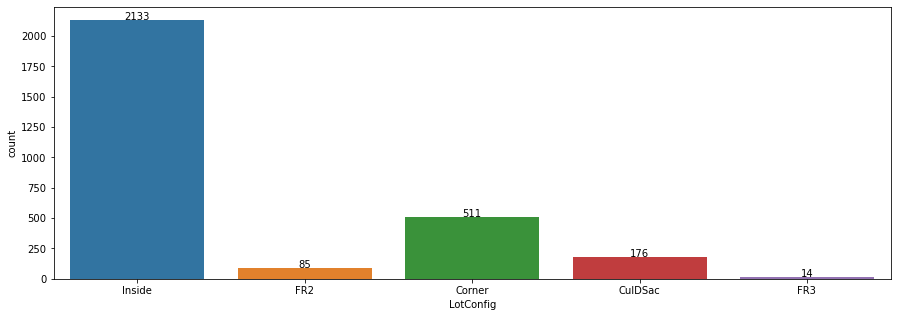

In [48]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['LotConfig'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()  

In [49]:
data['LotConfig'].isnull().sum()

0

In [50]:
dum = pd.get_dummies(data['LotConfig'], prefix='LotConfig')
dum
data = pd.concat([data,dum], axis=1)

In [51]:
data.drop(columns='LotConfig', inplace=True)
data

,Id,MSSubClass,LotFrontage,LotArea,Utilities,LandSlope,Neighborhood,Condition1,Condition2,BldgType,...,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside
0,1,5,65.0,9.042040,0,Gtl,CollgCr,Norm,Norm,1Fam,...,1,0,0,0,1,0,0,0,0,1
1,2,0,80.0,9.169623,0,Gtl,Veenker,Feedr,Norm,1Fam,...,1,0,0,0,1,0,0,1,0,0
2,3,5,68.0,9.328212,0,Gtl,CollgCr,Norm,Norm,1Fam,...,0,0,0,0,1,0,0,0,0,1
3,4,6,60.0,9.164401,0,Gtl,Crawfor,Norm,Norm,1Fam,...,0,0,0,0,1,1,0,0,0,0
4,5,5,84.0,9.565284,0,Gtl,NoRidge,Norm,Norm,1Fam,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,13,21.0,7.568896,0,Gtl,MeadowV,Norm,Norm,Twnhs,...,1,0,0,0,1,0,0,0,0,1
2915,2916,13,21.0,7.546974,0,Gtl,MeadowV,Norm,Norm,TwnhsE,...,1,0,0,0,1,0,0,0,0,1
2916,2917,0,160.0,9.903538,0,Gtl,Mitchel,Norm,Norm,1Fam,...,1,0,0,0,1,0,0,0,0,1
2917,2918,9,62.0,9.253591,0,Gtl,Mitchel,Norm,Norm,1Fam,...,1,0,0,0,1,0,0,0,0,1


**LandSlope column**

In [52]:
print(data['LandSlope'].nunique())
print(data['LandSlope'].isnull().sum())

3
0


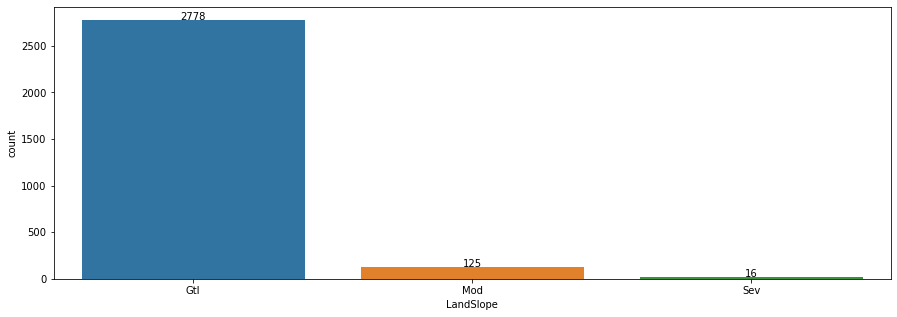

In [53]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['LandSlope'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()  

In [54]:
dum = pd.get_dummies(data['LandSlope'], prefix='LandSlope')
dum
data = pd.concat([data,dum], axis=1)

In [55]:
data.drop(columns='LandSlope', inplace=True)
data

,Id,MSSubClass,LotFrontage,LotArea,Utilities,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,...,LandContour_Low,LandContour_Lvl,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev
0,1,5,65.0,9.042040,0,CollgCr,Norm,Norm,1Fam,2Story,...,0,1,0,0,0,0,1,1,0,0
1,2,0,80.0,9.169623,0,Veenker,Feedr,Norm,1Fam,1Story,...,0,1,0,0,1,0,0,1,0,0
2,3,5,68.0,9.328212,0,CollgCr,Norm,Norm,1Fam,2Story,...,0,1,0,0,0,0,1,1,0,0
3,4,6,60.0,9.164401,0,Crawfor,Norm,Norm,1Fam,2Story,...,0,1,1,0,0,0,0,1,0,0
4,5,5,84.0,9.565284,0,NoRidge,Norm,Norm,1Fam,2Story,...,0,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,13,21.0,7.568896,0,MeadowV,Norm,Norm,Twnhs,2Story,...,0,1,0,0,0,0,1,1,0,0
2915,2916,13,21.0,7.546974,0,MeadowV,Norm,Norm,TwnhsE,2Story,...,0,1,0,0,0,0,1,1,0,0
2916,2917,0,160.0,9.903538,0,Mitchel,Norm,Norm,1Fam,1Story,...,0,1,0,0,0,0,1,1,0,0
2917,2918,9,62.0,9.253591,0,Mitchel,Norm,Norm,1Fam,SFoyer,...,0,1,0,0,0,0,1,1,0,0


**Neighborhood column**

In [56]:
print(data['Neighborhood'].nunique())
print(data['Neighborhood'].isnull().sum())

25
0


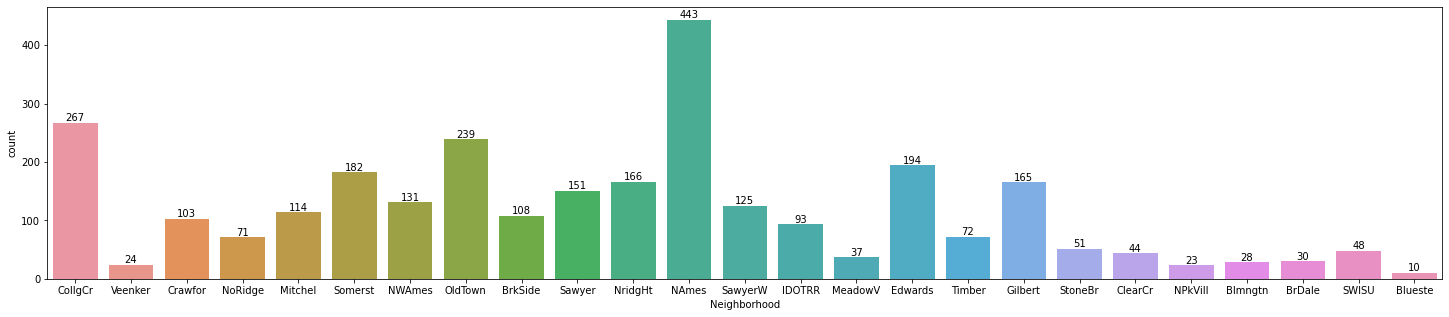

In [57]:
plt.figure(figsize=(25,5))
ax = sns.countplot(data['Neighborhood'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show() 

In [58]:
le = preprocessing.LabelEncoder()
data['Neighborhood'] = le.fit_transform(data['Neighborhood'])
data

,Id,MSSubClass,LotFrontage,LotArea,Utilities,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,...,LandContour_Low,LandContour_Lvl,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev
0,1,5,65.0,9.042040,0,5,Norm,Norm,1Fam,2Story,...,0,1,0,0,0,0,1,1,0,0
1,2,0,80.0,9.169623,0,24,Feedr,Norm,1Fam,1Story,...,0,1,0,0,1,0,0,1,0,0
2,3,5,68.0,9.328212,0,5,Norm,Norm,1Fam,2Story,...,0,1,0,0,0,0,1,1,0,0
3,4,6,60.0,9.164401,0,6,Norm,Norm,1Fam,2Story,...,0,1,1,0,0,0,0,1,0,0
4,5,5,84.0,9.565284,0,15,Norm,Norm,1Fam,2Story,...,0,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,13,21.0,7.568896,0,10,Norm,Norm,Twnhs,2Story,...,0,1,0,0,0,0,1,1,0,0
2915,2916,13,21.0,7.546974,0,10,Norm,Norm,TwnhsE,2Story,...,0,1,0,0,0,0,1,1,0,0
2916,2917,0,160.0,9.903538,0,11,Norm,Norm,1Fam,1Story,...,0,1,0,0,0,0,1,1,0,0
2917,2918,9,62.0,9.253591,0,11,Norm,Norm,1Fam,SFoyer,...,0,1,0,0,0,0,1,1,0,0


****Condition1 column****

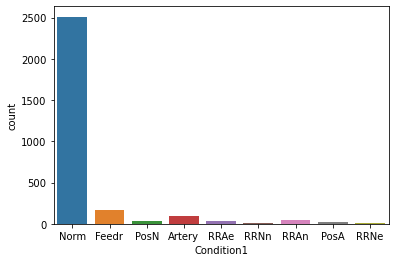

In [59]:
sns.countplot(data['Condition1'])

In [60]:
data['Condition1'] = data['Condition1'].map({'Norm':1,
                                            'Feedr':2,
                                            'PosN':3,
                                            'Artery':4,
                                            'RRAe':5,
                                            'RRNn':6,
                                            'RRAn':7,
                                            'PosA':8,
                                            'RRNe':9})

In [61]:
data['Condition2'] = data['Condition2'].map({'Norm':1,
                                            'Feedr':2,
                                            'PosN':3,
                                            'Artery':4,
                                            'RRAe':5,
                                            'RRNn':6,
                                            'RRAn':7,
                                            'PosA':8,})
                                            

**BldgType column**

In [62]:
print(data['BldgType'].isnull().sum())
print(data['BldgType'].nunique())

0
5


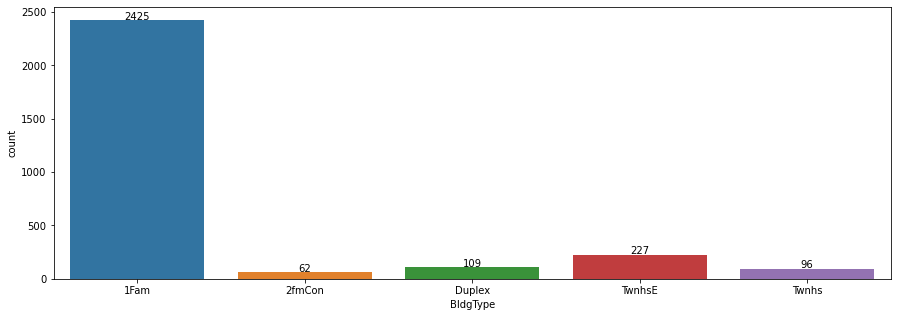

In [63]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['BldgType'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show() 

In [64]:
dum = pd.get_dummies(data['BldgType'], prefix='BldgType')
dum
data = pd.concat([data,dum], axis=1)

In [65]:
data.drop(columns='BldgType', inplace=True)

**HouseStyle column**

In [66]:
print(data['HouseStyle'].isnull().sum())
print(data['HouseStyle'].nunique())

0
8


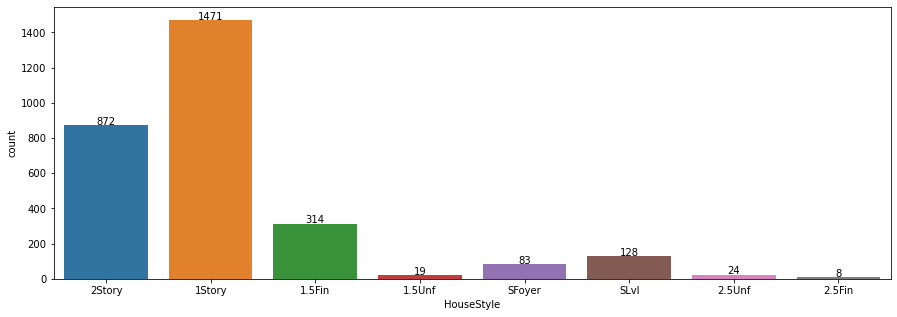

In [67]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['HouseStyle'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show() 

In [68]:
le = preprocessing.LabelEncoder()
data['HouseStyle'] = le.fit_transform(data['HouseStyle'])
data

,Id,MSSubClass,LotFrontage,LotArea,Utilities,Neighborhood,Condition1,Condition2,HouseStyle,OverallQual,...,LotConfig_FR3,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE
0,1,5,65.0,9.042040,0,5,1,1,5,7,...,0,1,1,0,0,1,0,0,0,0
1,2,0,80.0,9.169623,0,24,2,1,2,6,...,0,0,1,0,0,1,0,0,0,0
2,3,5,68.0,9.328212,0,5,1,1,5,7,...,0,1,1,0,0,1,0,0,0,0
3,4,6,60.0,9.164401,0,6,1,1,5,7,...,0,0,1,0,0,1,0,0,0,0
4,5,5,84.0,9.565284,0,15,1,1,5,8,...,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,13,21.0,7.568896,0,10,1,1,5,4,...,0,1,1,0,0,0,0,0,1,0
2915,2916,13,21.0,7.546974,0,10,1,1,5,4,...,0,1,1,0,0,0,0,0,0,1
2916,2917,0,160.0,9.903538,0,11,1,1,2,5,...,0,1,1,0,0,1,0,0,0,0
2917,2918,9,62.0,9.253591,0,11,1,1,6,5,...,0,1,1,0,0,1,0,0,0,0


In [69]:
data['Quality'] =  data['OverallQual'] + data['OverallCond']

In [70]:
skew(data['Quality'])

-0.5641233921894949

In [71]:
data.drop(columns=['OverallQual','OverallCond'], inplace=True)

In [72]:
data['YearBuilt'].nunique()

118

In [73]:
data['Date_diff'] = data['YearRemodAdd'] - data['YearBuilt']

skew(data['Date_diff'])


2.0637118903376805

In [74]:
data.drop(columns=['YearBuilt','YearRemodAdd'], inplace=True)

****RoofStyle column****

In [75]:
print(data['RoofStyle'].isnull().sum())
print(data['RoofStyle'].nunique())

0
6


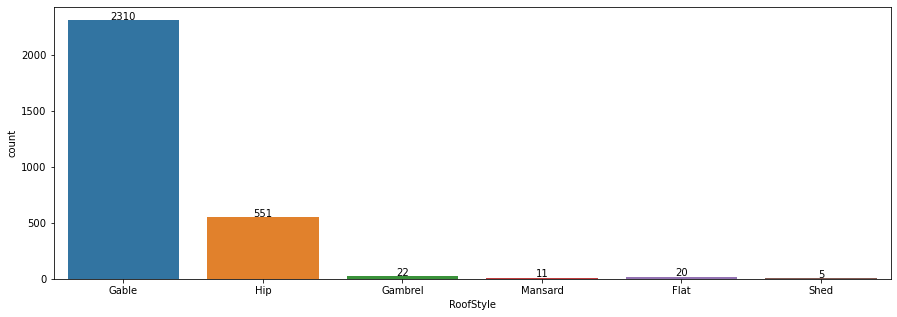

In [76]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['RoofStyle'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show() 

In [77]:
le = preprocessing.LabelEncoder()
data['RoofStyle'] = le.fit_transform(data['RoofStyle'])
data

,Id,MSSubClass,LotFrontage,LotArea,Utilities,Neighborhood,Condition1,Condition2,HouseStyle,RoofStyle,...,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,Quality,Date_diff
0,1,5,65.0,9.042040,0,5,1,1,5,1,...,1,0,0,1,0,0,0,0,12,0
1,2,0,80.0,9.169623,0,24,2,1,2,1,...,1,0,0,1,0,0,0,0,14,0
2,3,5,68.0,9.328212,0,5,1,1,5,1,...,1,0,0,1,0,0,0,0,12,1
3,4,6,60.0,9.164401,0,6,1,1,5,1,...,1,0,0,1,0,0,0,0,12,55
4,5,5,84.0,9.565284,0,15,1,1,5,1,...,1,0,0,1,0,0,0,0,13,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,13,21.0,7.568896,0,10,1,1,5,1,...,1,0,0,0,0,0,1,0,11,0
2915,2916,13,21.0,7.546974,0,10,1,1,5,1,...,1,0,0,0,0,0,0,1,9,0
2916,2917,0,160.0,9.903538,0,11,1,1,2,1,...,1,0,0,1,0,0,0,0,12,36
2917,2918,9,62.0,9.253591,0,11,1,1,6,1,...,1,0,0,1,0,0,0,0,10,0


**RoofMatl column**

In [78]:
print(data['RoofMatl'].isnull().sum())
print(data['RoofMatl'].nunique())

0
8


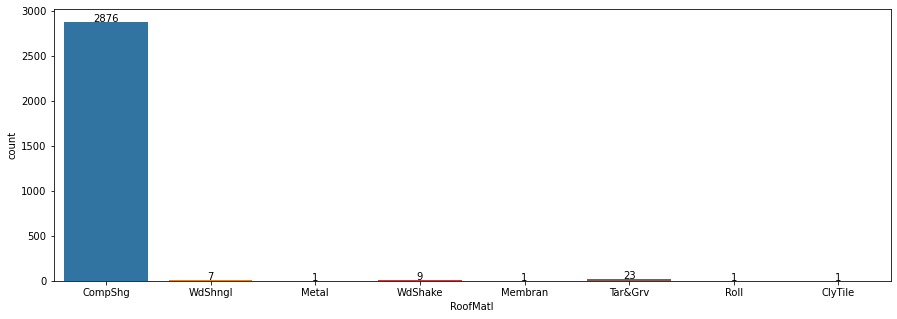

In [79]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['RoofMatl'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [80]:
le = preprocessing.LabelEncoder()
data['RoofMatl'] = le.fit_transform(data['RoofMatl'])
data['RoofMatl']

0       1
1       1
2       1
3       1
4       1
       ..
2914    1
2915    1
2916    1
2917    1
2918    1
Name: RoofMatl, Length: 2919, dtype: int64

**Exterior1st column**

In [81]:
print(data['Exterior1st'].isnull().sum())
print(data['Exterior1st'].nunique())

1
15


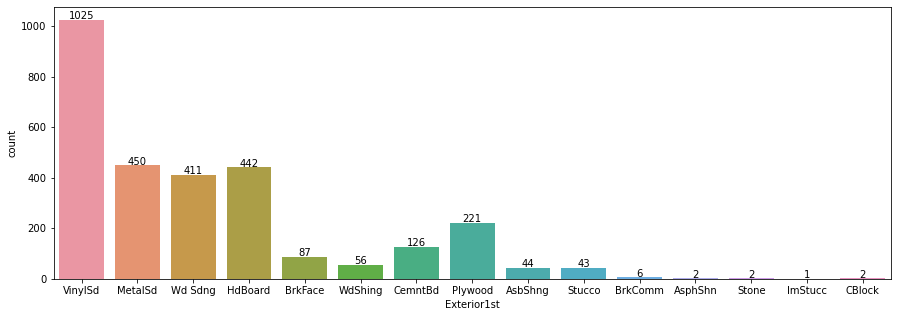

In [82]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['Exterior1st'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [83]:
data['Exterior1st'].fillna('VinylSd', inplace=True)

In [84]:
print(data['Exterior2nd'].isnull().sum())
print(data['Exterior2nd'].nunique())

1
16


In [85]:
data['Exterior2nd'].fillna('VinylSd', inplace=True)

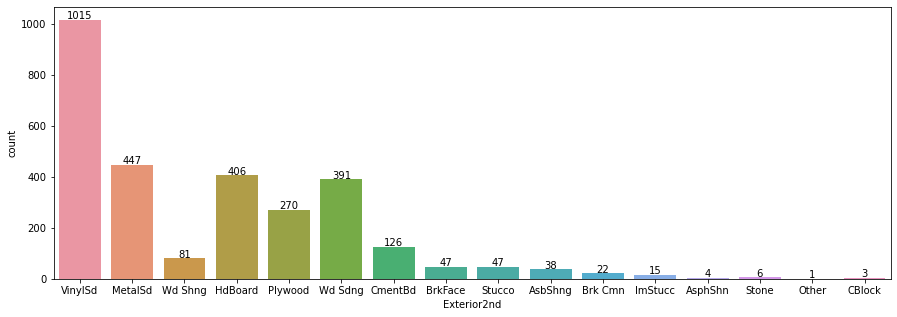

In [86]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['Exterior2nd'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [87]:


data['Exterior1st'] = data['Exterior1st'].map({'AsbShng':1,
                                              'AsphShn':2,
                                              'BrkComm':3,
                                              'BrkFace':4,
                                              'CBlock':5,
                                              'CemntBd':6,
                                              'HdBoard':7,
                                              'ImStucc':8,
                                              'MetalSd':9,
                                              'Plywood':10,
                                              'Stone':11,
                                              'Stucco':12,
                                              'VinylSd':13,
                                              'Wd Sdng':14,
                                              'WdShing':15})




data['Exterior2nd'] = data['Exterior2nd'].map({'Other' :0,
                                              'AsbShng':1,
                                              'AsphShn':2,
                                              'Brk Cmn':3,
                                              'BrkFace':4,
                                              'CBlock':5,
                                              'CmentBd':6,
                                              'HdBoard':7,
                                              'ImStucc':8,
                                              'MetalSd':9,
                                              'Plywood':10,
                                              'Stone':11,
                                              'Stucco':12,
                                              'VinylSd':13,
                                              'Wd Sdng':14,
                                              'Wd Shng':15})

data.iloc[:,9:].head(12)

,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,...,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,Quality,Date_diff
0,1,1,13,13,BrkFace,196.0,Gd,TA,PConc,Gd,...,1,0,0,1,0,0,0,0,12,0
1,1,1,9,9,None,0.0,TA,TA,CBlock,Gd,...,1,0,0,1,0,0,0,0,14,0
2,1,1,13,13,BrkFace,162.0,Gd,TA,PConc,Gd,...,1,0,0,1,0,0,0,0,12,1
3,1,1,14,15,None,0.0,TA,TA,BrkTil,TA,...,1,0,0,1,0,0,0,0,12,55
4,1,1,13,13,BrkFace,350.0,Gd,TA,PConc,Gd,...,1,0,0,1,0,0,0,0,13,0
5,1,1,13,13,None,0.0,TA,TA,Wood,Gd,...,1,0,0,1,0,0,0,0,10,2
6,1,1,13,13,Stone,186.0,Gd,TA,PConc,Ex,...,1,0,0,1,0,0,0,0,13,1
7,1,1,7,7,Stone,240.0,TA,TA,CBlock,Gd,...,1,0,0,1,0,0,0,0,13,0
8,1,1,4,15,None,0.0,TA,TA,BrkTil,TA,...,1,0,0,1,0,0,0,0,12,19
9,1,1,9,9,None,0.0,TA,TA,BrkTil,TA,...,1,0,0,0,1,0,0,0,11,11


**MasVnrType column**

In [88]:
print(data['MasVnrType'].isnull().sum())
print(data['MasVnrType'].nunique())

24
4


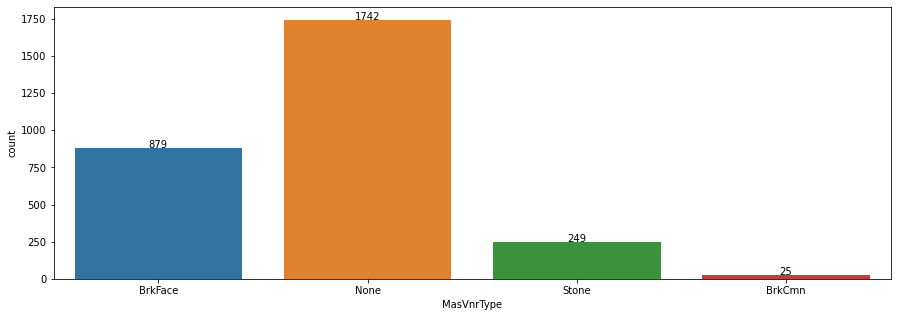

In [89]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['MasVnrType'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [90]:
data['MasVnrType'].fillna('None', inplace=True)


In [91]:
dum = pd.get_dummies(data['MasVnrType'], prefix='MasVnrType', drop_first=True)
data = pd.concat([data,dum], axis=1)
data

,Id,MSSubClass,LotFrontage,LotArea,Utilities,Neighborhood,Condition1,Condition2,HouseStyle,RoofStyle,...,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,Quality,Date_diff,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone
0,1,5,65.0,9.042040,0,5,1,1,5,1,...,1,0,0,0,0,12,0,1,0,0
1,2,0,80.0,9.169623,0,24,2,1,2,1,...,1,0,0,0,0,14,0,0,1,0
2,3,5,68.0,9.328212,0,5,1,1,5,1,...,1,0,0,0,0,12,1,1,0,0
3,4,6,60.0,9.164401,0,6,1,1,5,1,...,1,0,0,0,0,12,55,0,1,0
4,5,5,84.0,9.565284,0,15,1,1,5,1,...,1,0,0,0,0,13,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,13,21.0,7.568896,0,10,1,1,5,1,...,0,0,0,1,0,11,0,0,1,0
2915,2916,13,21.0,7.546974,0,10,1,1,5,1,...,0,0,0,0,1,9,0,0,1,0
2916,2917,0,160.0,9.903538,0,11,1,1,2,1,...,1,0,0,0,0,12,36,0,1,0
2917,2918,9,62.0,9.253591,0,11,1,1,6,1,...,1,0,0,0,0,10,0,0,1,0


In [92]:
data.drop(columns='MasVnrType', inplace=True)


**MasVnrArea column**

In [286]:
print(data['MasVnrArea'].isnull().sum())
print(data['MasVnrArea'].nunique())

0
445


In [285]:
from sklearn.impute import KNNImputer
imputer = KNNImputer( n_neighbors=10, metric='nan_euclidean',weights='uniform')
x = imputer.fit_transform(data[['MasVnrArea']]) 
Xtrans = imputer.transform(x)
data['MasVnrArea'] = Xtrans


,Id,MSSubClass,LotFrontage,LotArea,Utilities,Neighborhood,Condition1,Condition2,HouseStyle,RoofStyle,...,Exter_quality,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,GarageFinish_0,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,Garage_Quality
0,1,5,65.000000,9.042040,0,5,1,1,5,1,...,3,0,0,1,0,0,0,1,0,6
1,2,0,80.000000,9.169623,0,24,2,1,2,1,...,2,0,0,0,1,0,0,1,0,6
2,3,5,68.000000,9.328212,0,5,1,1,5,1,...,3,0,0,1,0,0,0,1,0,6
3,4,6,60.000000,9.164401,0,6,1,1,5,1,...,2,0,0,1,0,0,0,0,1,6
4,5,5,84.000000,9.565284,0,15,1,1,5,1,...,3,0,0,1,0,0,0,1,0,6
5,6,4,85.000000,9.555064,0,11,1,1,0,1,...,2,0,0,0,1,0,0,0,1,6
6,7,0,75.000000,9.218804,0,21,1,1,2,1,...,3,0,0,1,0,0,0,1,0,6
7,8,5,69.305795,9.247925,0,14,3,1,5,1,...,2,0,0,0,1,0,0,1,0,6
8,9,4,51.000000,8.719481,0,17,4,1,0,1,...,2,0,0,0,1,0,0,0,1,5
9,10,15,50.000000,8.912069,0,3,4,4,1,1,...,2,0,0,0,1,0,0,1,0,7


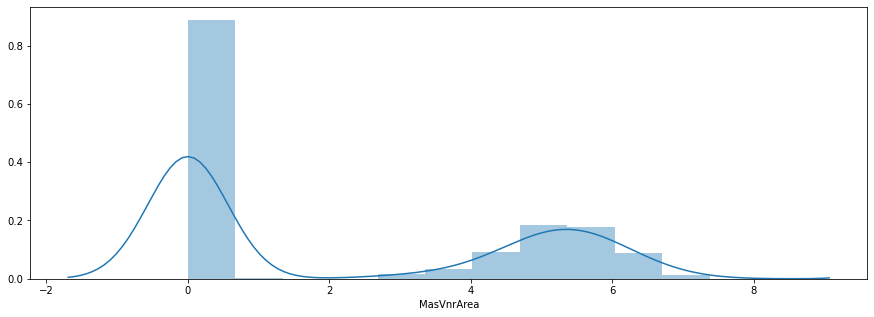

In [291]:
plt.figure(figsize=(15,5))
sns.distplot(data['MasVnrArea'])

In [289]:
print(skew(data['MasVnrArea']))
a = np.log1p(data['MasVnrArea'])
skew(a)

2.6115493751087344


0.504572505911369

In [290]:
data['MasVnrArea'] = np.log1p(data['MasVnrArea'])
skew(data['MasVnrArea'])

0.504572505911369

****ExterQual column

In [93]:
print(data['ExterQual'].isnull().sum())
print(data['ExterQual'].nunique())

0
4


In [94]:
print(data['ExterCond'].isnull().sum())
print(data['ExterCond'].nunique())

0
5


ExterQual


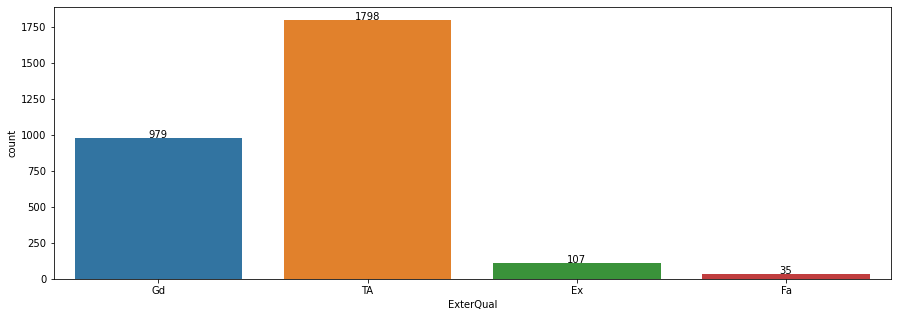

ExterCond


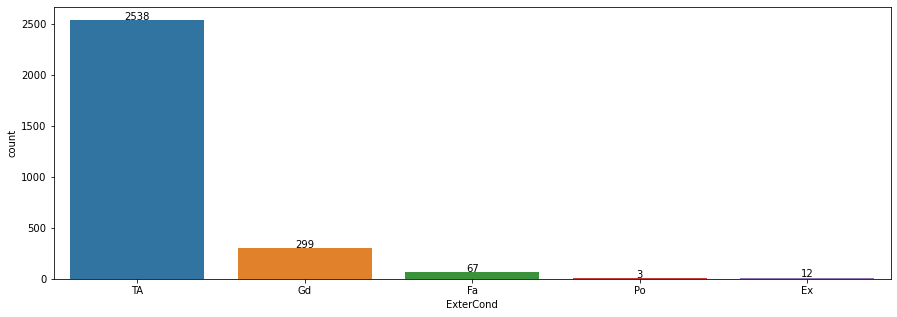

In [95]:
d = ['ExterQual','ExterCond']
for i in d:
    print(i)
    plt.figure(figsize=(15,5))
    ax = sns.countplot(data[i])
    for p in ax.patches:
        h = p.get_height()
        w = p.get_width()/2
        ax.text(p.get_x()+w, h+3,
                '{:1}'.format(h),
               ha="center")
    plt.show()

In [96]:

data['ExterCond'] = data['ExterCond'].map({   'Po':0,
                                              'TA':1,
                                              'Gd':2,
                                              'Fa':3,
                                              'Ex':4,})
data['ExterQual'] = data['ExterQual'].map({   
                                              'TA':1,
                                              'Gd':2,
                                              'Fa':3,
                                              'Ex':4,})

data.iloc[:,11:].head(12)

,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,...,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,Quality,Date_diff,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone
0,13,13,196.0,2,1,PConc,Gd,TA,No,GLQ,...,1,0,0,0,0,12,0,1,0,0
1,9,9,0.0,1,1,CBlock,Gd,TA,Gd,ALQ,...,1,0,0,0,0,14,0,0,1,0
2,13,13,162.0,2,1,PConc,Gd,TA,Mn,GLQ,...,1,0,0,0,0,12,1,1,0,0
3,14,15,0.0,1,1,BrkTil,TA,Gd,No,ALQ,...,1,0,0,0,0,12,55,0,1,0
4,13,13,350.0,2,1,PConc,Gd,TA,Av,GLQ,...,1,0,0,0,0,13,0,1,0,0
5,13,13,0.0,1,1,Wood,Gd,TA,No,GLQ,...,1,0,0,0,0,10,2,0,1,0
6,13,13,186.0,2,1,PConc,Ex,TA,Av,GLQ,...,1,0,0,0,0,13,1,0,0,1
7,7,7,240.0,1,1,CBlock,Gd,TA,Mn,ALQ,...,1,0,0,0,0,13,0,0,0,1
8,4,15,0.0,1,1,BrkTil,TA,TA,No,Unf,...,1,0,0,0,0,12,19,0,1,0
9,9,9,0.0,1,1,BrkTil,TA,TA,No,GLQ,...,0,1,0,0,0,11,11,0,1,0


In [97]:
data['Exter_quality'] = data['ExterCond'] + data['ExterQual']

In [98]:
data.drop(columns=['ExterCond','ExterQual'],inplace=True)

**Foundation column**

In [99]:
print(data['Foundation'].isnull().sum())
print(data['Foundation'].nunique())

0
6


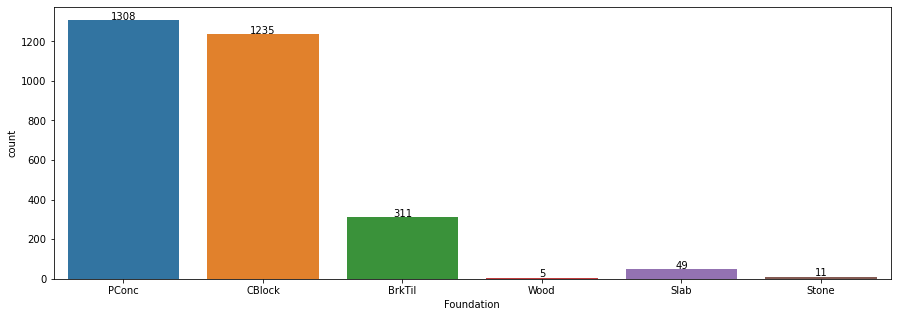

In [100]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['Foundation'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [101]:
le = preprocessing.LabelEncoder()
data['Foundation'] = le.fit_transform(data['Foundation'])

In [102]:
print(data['BsmtQual'].isnull().sum())
print(data['BsmtQual'].nunique())

81
4


In [103]:
data['BsmtQual'].fillna(0, inplace=True)

In [104]:
print(data['BsmtCond'].isnull().sum())
print(data['BsmtCond'].nunique())

82
4


In [105]:
data['BsmtCond'].fillna(0, inplace=True)

In [106]:
print(data['BsmtExposure'].isnull().sum())
print(data['BsmtExposure'].nunique())

82
4


In [107]:
data['BsmtExposure'].fillna(0, inplace=True)

BsmtQual


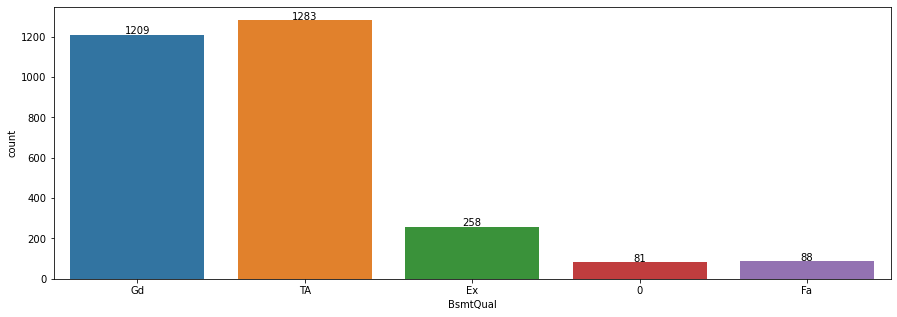

BsmtCond


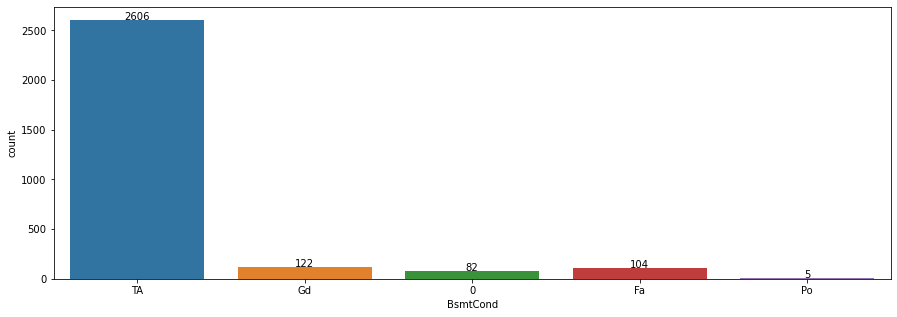

BsmtExposure


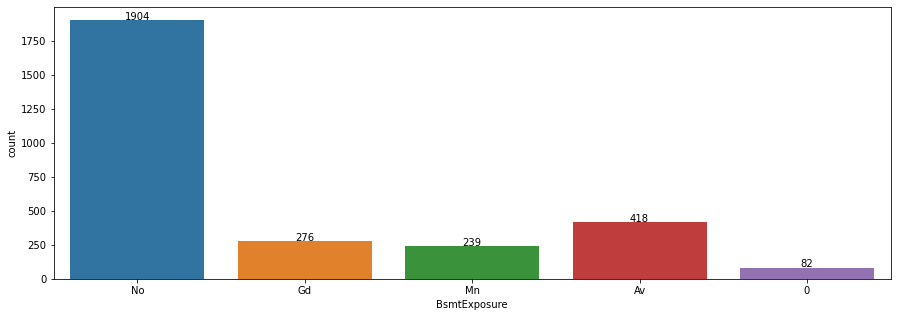

In [108]:
d = ['BsmtQual','BsmtCond','BsmtExposure']
for i in d:
    print(i)
    plt.figure(figsize=(15,5))
    ax = sns.countplot(data[i])
    for p in ax.patches:
        h = p.get_height()
        w = p.get_width()/2
        ax.text(p.get_x()+w, h+3,
                '{:1}'.format(h),
               ha="center")
    plt.show()

In [109]:
data['BsmtExposure'] = data['BsmtExposure'].map({
                                         'Gd':4,
                                         'Av':3,
                                         'Mn':2,
                                         'No':1,
                                          0:0,
                                         })
data['BsmtCond'] = data['BsmtCond'].map({
                                         'Gd':4,
                                         'TA':3,
                                         'Fa':2,
                                         'Po':1,
                                          0:0,
                                         })
data['BsmtQual'] = data['BsmtQual'].map({'Ex':5,
                                         'Gd':4,
                                         'TA':3,
                                         'Fa':2,
                                          0:0,
                                         })


In [110]:
print(data['BsmtFinType1'].isnull().sum())
print(data['BsmtFinType1'].nunique())

79
6


In [111]:
data['BsmtFinType1'].fillna(0, inplace=True)

In [112]:
print(data['BsmtFinType2'].isnull().sum())
print(data['BsmtFinType2'].nunique())

80
6


In [113]:
data['BsmtFinType2'].fillna(0, inplace=True)

BsmtFinType1


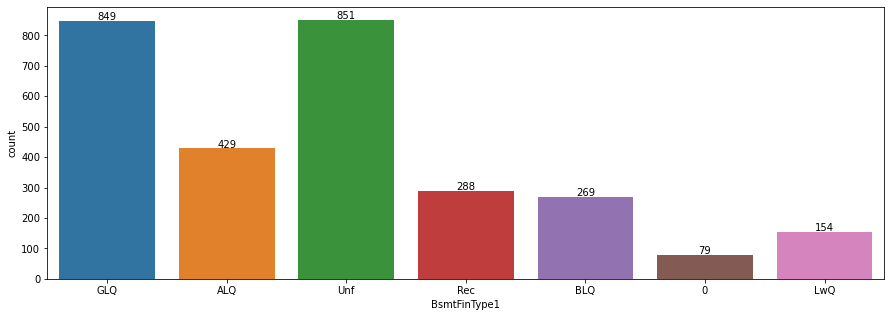

BsmtFinType2


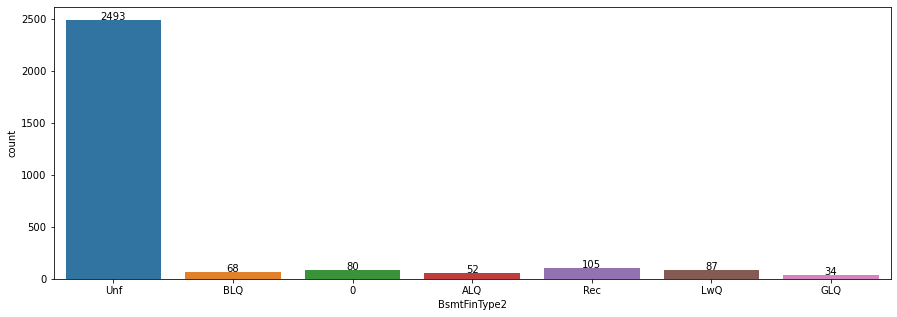

In [114]:
d = ['BsmtFinType1','BsmtFinType2']
for i in d:
    print(i)
    plt.figure(figsize=(15,5))
    ax = sns.countplot(data[i])
    for p in ax.patches:
        h = p.get_height()
        w = p.get_width()/2
        ax.text(p.get_x()+w, h+3,
                '{:1}'.format(h),
               ha="center")
    plt.show()

In [115]:
data['BsmtFinType1'] = data['BsmtFinType1'].map({
                        'GLQ':6,
                        'ALQ':5,
                        'BLQ':4,
                        'Rec':3,
                        'LwQ':2,
                        'Unf':1,
                        0:0
                            })

data['BsmtFinType2'] = data['BsmtFinType2'].map({
                        'GLQ':6,
                        'ALQ':5,
                        'BLQ':4,
                        'Rec':3,
                        'LwQ':2,
                        'Unf':1,
                        0:0
                            })

**few columns need  to drop**

In [116]:
# BsmtFinSF1, BsmtFinSF2, BsmtUnfSF lets drop them

In [117]:
data.drop(columns=['BsmtFinSF1','BsmtFinSF2','BsmtUnfSF'], inplace=True)

**TotalBsmtSF column**

In [118]:
print(data['TotalBsmtSF'].isnull().sum())
print(data['TotalBsmtSF'].nunique())

1
1058


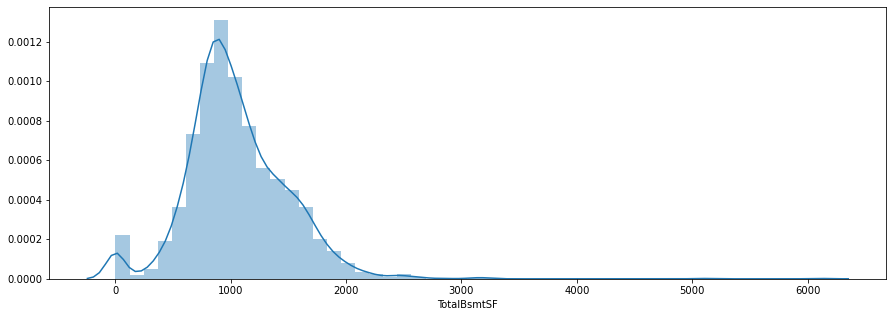

In [119]:
plt.figure(figsize=(15,5))
sns.distplot(data['TotalBsmtSF'])

In [120]:
from sklearn.impute import KNNImputer
imputer = KNNImputer( n_neighbors=10, metric='nan_euclidean',weights='uniform')
x = imputer.fit_transform(data[['TotalBsmtSF']]) 
Xtrans = imputer.transform(x)
Xtrans
data['TotalBsmtSF'] = Xtrans


In [121]:

skew(data['TotalBsmtSF'])

1.1624837493331972

**Heating column**

In [122]:
print(data['Heating'].isnull().sum())
print(data['Heating'].nunique())

0
6


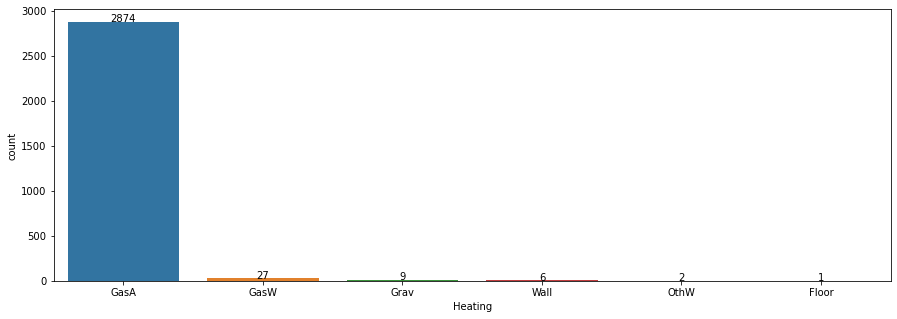

In [123]:

plt.figure(figsize=(15,5))
ax = sns.countplot(data['Heating'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [124]:
le = preprocessing.LabelEncoder()
data['Heating'] = le.fit_transform(data['Heating'])


**HeatingQC column**

In [125]:
print(data['HeatingQC'].isnull().sum())
print(data['HeatingQC'].nunique())

0
5


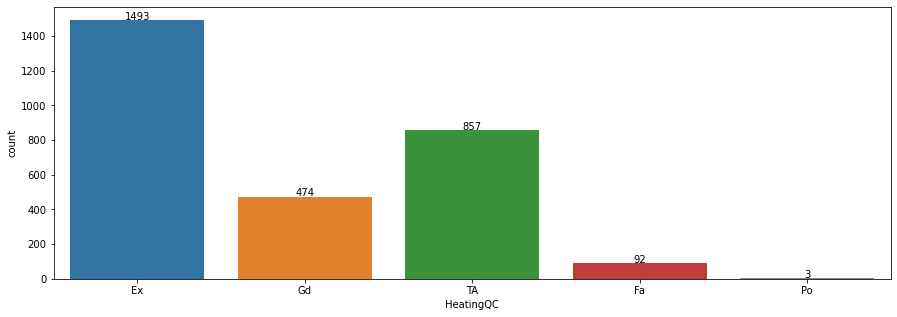

In [126]:

plt.figure(figsize=(15,5))
ax = sns.countplot(data['HeatingQC'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [127]:
data['HeatingQC'] = data['HeatingQC'].map({
                                        'Ex':5,
                                        'Gd':4,
                                        'TA':3,
                                        'Fa':2,
                                        'Po':1
    
})

**CentralAir column**

In [128]:
print(data['CentralAir'].isnull().sum())
print(data['CentralAir'].nunique())

0
2


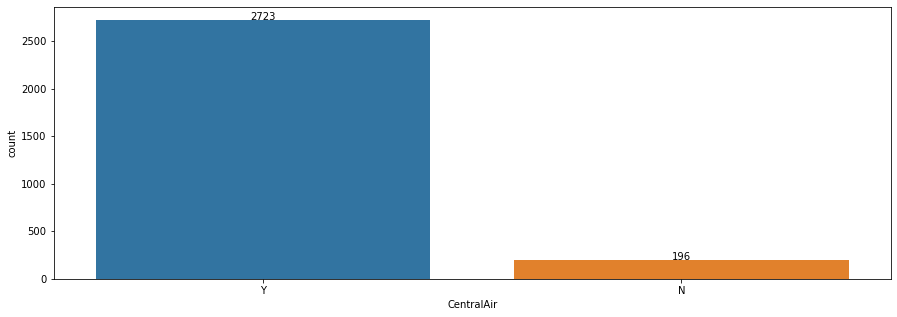

In [129]:

plt.figure(figsize=(15,5))
ax = sns.countplot(data['CentralAir'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [130]:
le = preprocessing.LabelEncoder()
data['CentralAir'] = le.fit_transform(data['CentralAir'])

**Electrical column**

In [131]:
print(data['Electrical'].isnull().sum())
print(data['Electrical'].nunique())

1
5


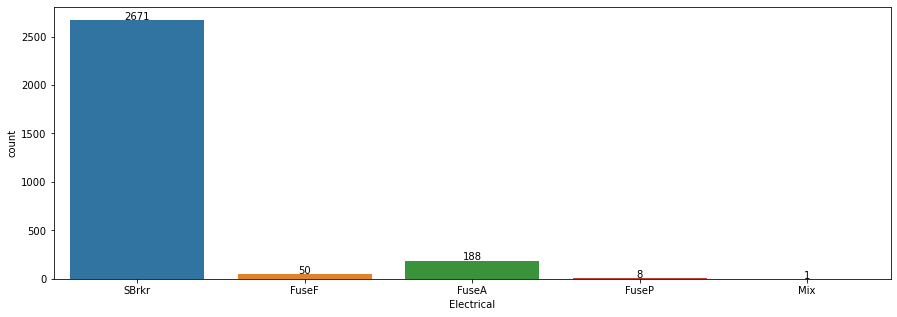

In [132]:

plt.figure(figsize=(15,5))
ax = sns.countplot(data['Electrical'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [133]:
data['Electrical'].fillna('SBrkr', inplace=True)

In [134]:
le = preprocessing.LabelEncoder()
data['Electrical'] = le.fit_transform(data['Electrical'])

**GrLivArea Column**

In [135]:
print(data['GrLivArea'].isnull().sum())
print(data['GrLivArea'].nunique())

0
1292


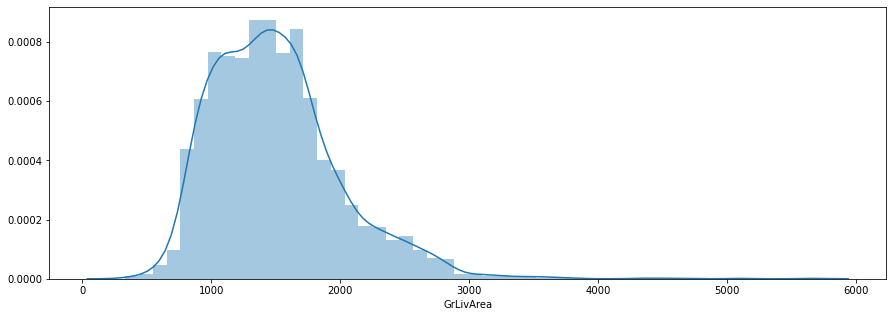

In [136]:
plt.figure(figsize=(15,5))
sns.distplot(data['GrLivArea'])

In [137]:
print(skew(data['GrLivArea']))
data['GrLivArea'] = np.log1p(data['GrLivArea'])

1.269357688230336


In [138]:
skew(data['GrLivArea'])

0.013187581757008803

In [139]:
data.drop(columns=['1stFlrSF','2ndFlrSF','LowQualFinSF'], inplace=True)

**KitchenQual column**

In [140]:
print(data['KitchenQual'].isnull().sum())
print(data['KitchenQual'].nunique())

1
4


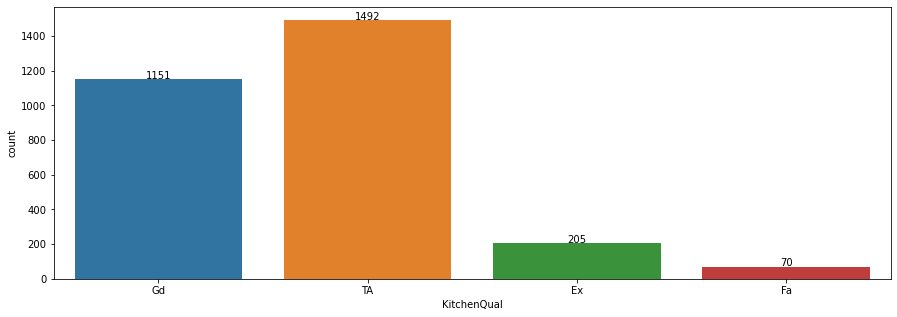

In [141]:

plt.figure(figsize=(15,5))
ax = sns.countplot(data['KitchenQual'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [142]:
data['KitchenQual'].fillna('TA', inplace=True)

In [143]:
dum = pd.get_dummies(data['KitchenQual'], prefix='KitchenQual')
dum
data = pd.concat([data,dum], axis=1)


In [144]:
data.drop(columns=['KitchenQual'], inplace=True)

Functional column

In [145]:
print(data['Functional'].isnull().sum())
print(data['Functional'].nunique())

2
7


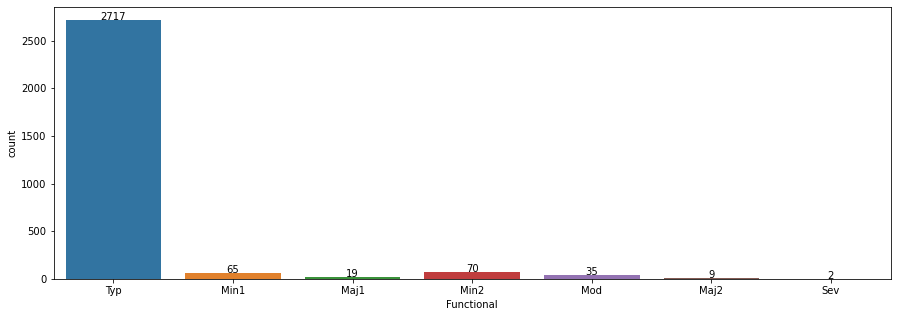

In [146]:

plt.figure(figsize=(15,5))
ax = sns.countplot(data['Functional'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [147]:
data['Functional'].fillna('Typ', inplace=True)

In [148]:
le = preprocessing.LabelEncoder()
data['Functional'] = le.fit_transform(data['Functional'])

In [149]:
print(data['FireplaceQu'].isnull().sum())
print(data['FireplaceQu'].nunique())

1420
5


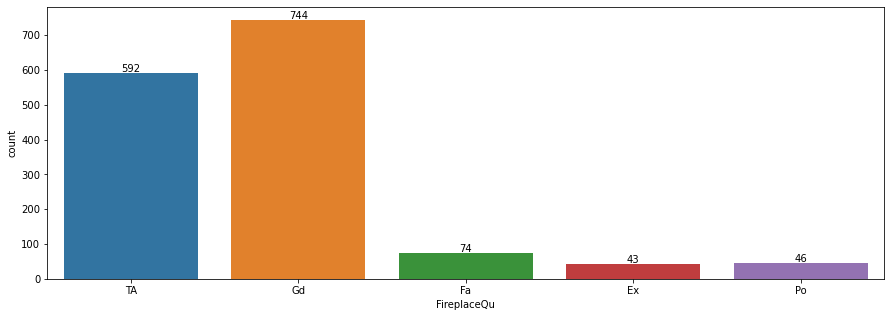

In [150]:

plt.figure(figsize=(15,5))
ax = sns.countplot(data['FireplaceQu'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [151]:
data['FireplaceQu'].fillna(0, inplace=True)

In [152]:
data['FireplaceQu'] = data['FireplaceQu'].map({
                                            'Ex':5,
                                            'Gd':4,
                                            'TA':3,
                                            'Fa':2,
                                            'Po':1,
                                             0:0
                                            
})

**GarageType column**

In [153]:
print(data['GarageType'].isnull().sum())
print(data['GarageType'].nunique())

157
6


In [154]:
data['GarageType'].fillna(0, inplace=True)

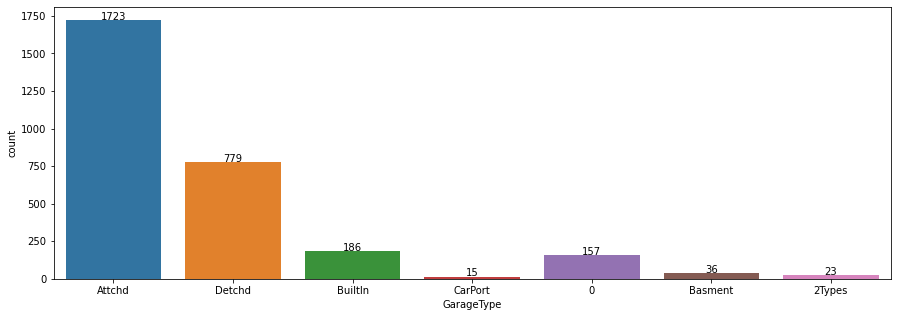

In [155]:

plt.figure(figsize=(15,5))
ax = sns.countplot(data['GarageType'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [156]:
data['GarageType'] = data['GarageType'].map({
                                            '2Types':6,
                                            'Attchd':5,
                                            'Basment':4,
                                            'BuiltIn':3,
                                            'CarPort':2,
                                            'Detchd':1,
                                                0:0
})

GarageYrBlt column

In [157]:
data.drop(columns='GarageYrBlt', inplace=True)

**GarageFinish column**

In [158]:
print(data['GarageFinish'].isnull().sum())
print(data['GarageFinish'].nunique())

159
3


In [159]:
data['GarageFinish'].fillna('0', inplace=True)

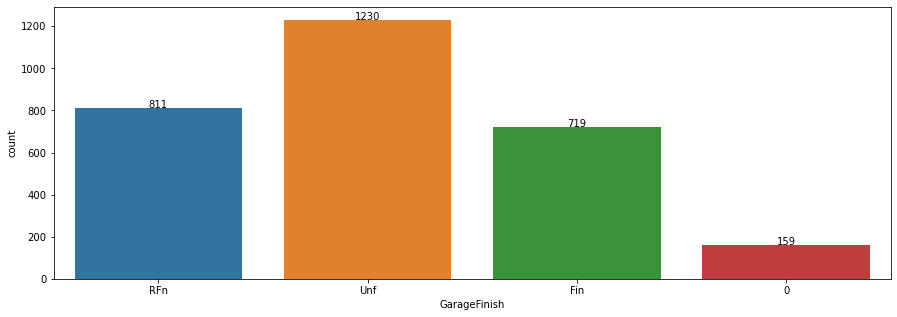

In [160]:

plt.figure(figsize=(15,5))
ax = sns.countplot(data['GarageFinish'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [161]:
dum = pd.get_dummies(data['GarageFinish'], prefix='GarageFinish')
dum
data = pd.concat([data,dum], axis=1)


In [162]:
data.drop(columns='GarageFinish', inplace=True)

**GarageArea column**

In [166]:
print(data['GarageArea'].isnull().sum())
print(data['GarageArea'].nunique())

0
603


In [165]:
data['GarageArea'].fillna(0, inplace=True)

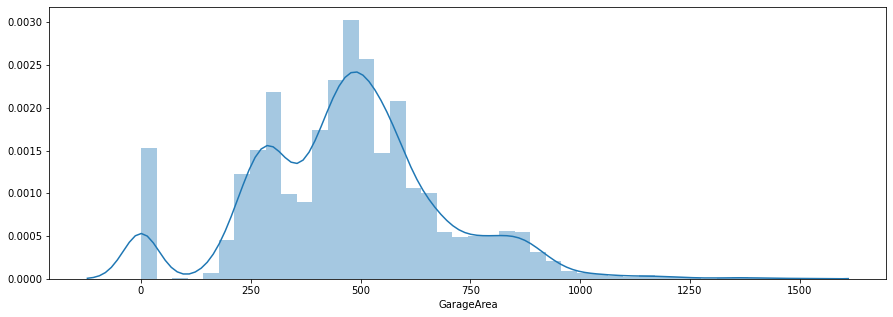

In [168]:
plt.figure(figsize=(15,5))
sns.distplot(data['GarageArea'])

In [170]:
print(skew(data['GarageArea']))
a = np.log1p(data['GarageArea'])
skew(a)

0.23925692009788638


-3.5104519909635914

as skew value in normal so no need of normalization

**GarageQual column**

In [175]:
print(data['GarageQual'].isnull().sum())
print(data['GarageQual'].nunique())

0
6


In [174]:
data['GarageQual'].fillna(0, inplace=True)

In [176]:
print(data['GarageCond'].isnull().sum())
print(data['GarageCond'].nunique())

0
6


In [173]:
data['GarageCond'].fillna(0, inplace=True)

GarageQual


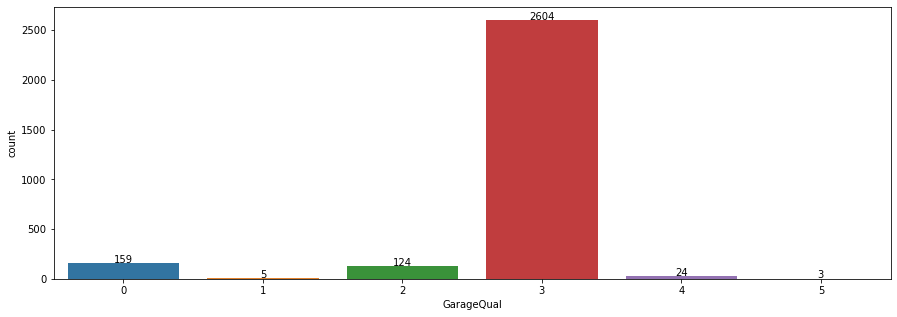

GarageCond


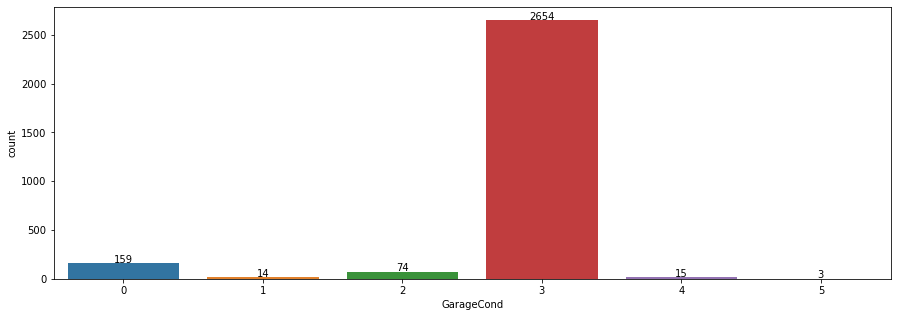

In [183]:
i = ['GarageQual','GarageCond']

for a in i:
    print(a)
    
    plt.figure(figsize=(15,5))
    ax = sns.countplot(data[a])
    for p in ax.patches:
        h = p.get_height()
        w = p.get_width()/2
        ax.text(p.get_x()+w, h+3,
                '{:1}'.format(h),
               ha="center")
    plt.show()


In [182]:
data['GarageQual'] = data['GarageQual'].map({
                                        'Ex':5,
                                        'Gd':4,
                                        'TA':3,
                                        'Fa':2,
                                        'Po':1,
                                        0:0
})

data['GarageCond'] = data['GarageCond'].map({
                                        'Ex':5,
                                        'Gd':4,
                                        'TA':3,
                                        'Fa':2,
                                        'Po':1,
                                        0:0
})

In [188]:
data['Garage_Quality'] = data['GarageQual'] + data['GarageCond']


,Id,MSSubClass,LotFrontage,LotArea,Utilities,Neighborhood,Condition1,Condition2,HouseStyle,RoofStyle,...,Exter_quality,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,GarageFinish_0,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,Garage_Quality
0,1,5,65.0,9.042040,0,5,1,1,5,1,...,3,0,0,1,0,0,0,1,0,6
1,2,0,80.0,9.169623,0,24,2,1,2,1,...,2,0,0,0,1,0,0,1,0,6
2,3,5,68.0,9.328212,0,5,1,1,5,1,...,3,0,0,1,0,0,0,1,0,6
3,4,6,60.0,9.164401,0,6,1,1,5,1,...,2,0,0,1,0,0,0,0,1,6
4,5,5,84.0,9.565284,0,15,1,1,5,1,...,3,0,0,1,0,0,0,1,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,13,21.0,7.568896,0,10,1,1,5,1,...,2,0,0,0,1,1,0,0,0,0
2915,2916,13,21.0,7.546974,0,10,1,1,5,1,...,2,0,0,0,1,0,0,0,1,6
2916,2917,0,160.0,9.903538,0,11,1,1,2,1,...,2,0,0,0,1,0,0,0,1,6
2917,2918,9,62.0,9.253591,0,11,1,1,6,1,...,2,0,0,0,1,1,0,0,0,0


In [190]:
data.drop(columns=['GarageQual','GarageCond'], inplace=True)

**PavedDrive column**

In [191]:
print(data['PavedDrive'].isnull().sum())
print(data['PavedDrive'].nunique())

0
3


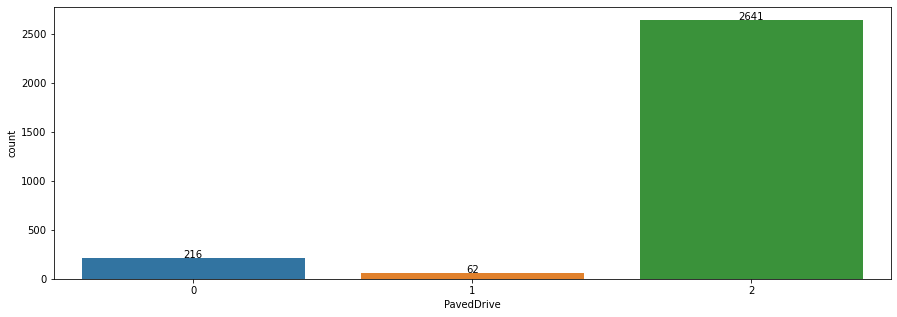

In [192]:

plt.figure(figsize=(15,5))
ax = sns.countplot(data['PavedDrive'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()


In [186]:
data['PavedDrive'] = data['PavedDrive'].map({
                                        'Y':2,
                                        'P':1,
                                        'N':0
})

*WoodDeckSF column*

In [193]:
print(data['WoodDeckSF'].isnull().sum())
print(data['WoodDeckSF'].nunique())

0
379


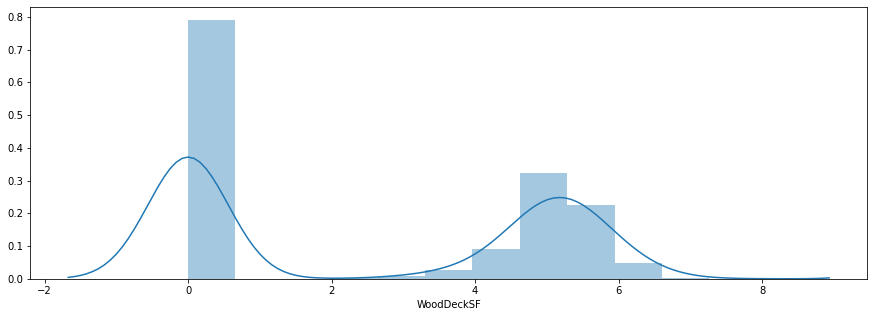

In [198]:
plt.figure(figsize=(15,5))
sns.distplot(data['WoodDeckSF'])

In [196]:
print(skew(data['WoodDeckSF']))
a = np.log1p(data['WoodDeckSF'])
skew(a)

1.8424328111184782


0.1580330005981843

**as skew value imporver after regularization so we will do log operation**

In [197]:
data['WoodDeckSF'] = np.log1p(data['WoodDeckSF'])
skew(data['WoodDeckSF'])

0.1580330005981843

***OpenPorchSF column***

In [199]:
print(data['OpenPorchSF'].isnull().sum())
print(data['OpenPorchSF'].nunique())

0
252


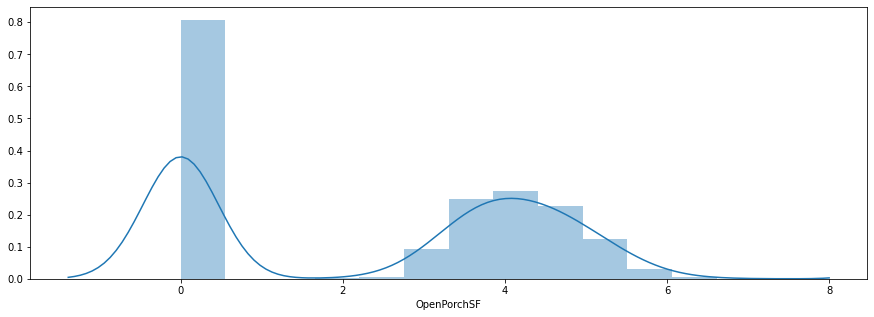

In [203]:
plt.figure(figsize=(15,5))
sns.distplot(data['OpenPorchSF'])

In [201]:
print(skew(data['OpenPorchSF']))
a = np.log1p(data['OpenPorchSF'])
skew(a)

2.5351137294802557


-0.041797304052571066

In [202]:
data['OpenPorchSF'] = np.log1p(data['OpenPorchSF'])
skew(data['OpenPorchSF'])

-0.041797304052571066

**EnclosedPorch column**

In [204]:
print(data['EnclosedPorch'].isnull().sum())
print(data['EnclosedPorch'].nunique())

0
183


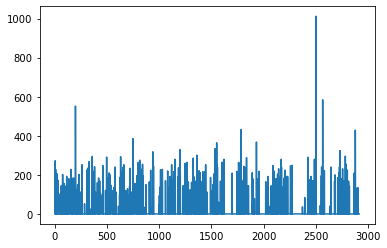

In [222]:
data['EnclosedPorch'].plot()

In [223]:
print(skew(data['EnclosedPorch']))
a = np.log1p(data['EnclosedPorch'])
skew(a)

4.003891220540856


1.961080589820378

In [225]:
data['EnclosedPorch'] = np.log1p(data['EnclosedPorch'])
skew(data['EnclosedPorch'])

1.961080589820378

**3SsnPorch column**

In [226]:
print(data['3SsnPorch'].isnull().sum())
print(data['3SsnPorch'].nunique())

0
31


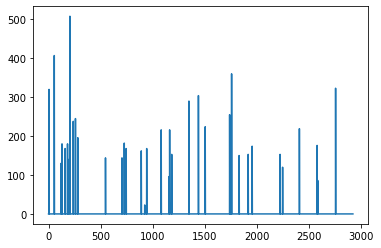

In [227]:
data['3SsnPorch'].plot()

In [233]:
print(skew(data['3SsnPorch']))
a = np.log1p(data['3SsnPorch'])
# a = np.log(a)
skew(a)

11.376064682827481


8.82525576505377

as data is highly skewed so i decided to remover these three column 3SsnPorch, ScreenPorch, PoolArea

In [236]:
data.drop(columns=['3SsnPorch','ScreenPorch','PoolArea'], inplace=True)

PoolQC column

In [239]:
print(data['PoolQC'].isnull().sum())
print(data['PoolQC'].nunique())

0
4


In [238]:
data['PoolQC'].fillna(0, inplace=True)

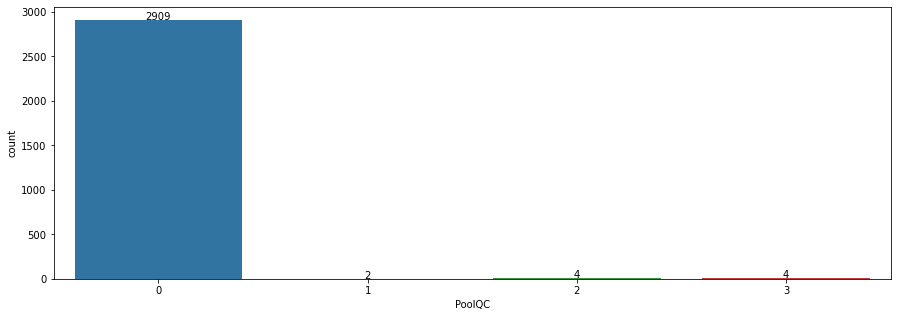

In [242]:

plt.figure(figsize=(15,5))
ax = sns.countplot(data['PoolQC'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()


In [241]:
data['PoolQC'] = data['PoolQC'].map({
                                    'Ex':3,
                                    'Gd':2,
                                    'Fa':1,
                                        0:0
})

Fence column

In [248]:
print(data['Fence'].isnull().sum())
print(data['Fence'].nunique())

0
5


In [244]:
data['Fence'].fillna(0, inplace=True)

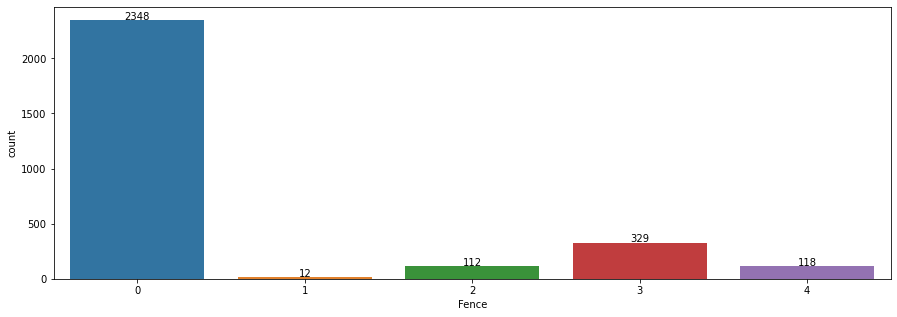

In [247]:

plt.figure(figsize=(15,5))
ax = sns.countplot(data['Fence'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()


In [246]:
data['Fence'] = data['Fence'].map({
                                'GdPrv':4,
                                'MnPrv':3,
                                'GdWo':2,
                                'MnWw':1,
                                0:0
})

MiscFeature column

In [255]:
print(data['MiscFeature'].isnull().sum())
print(data['MiscFeature'].nunique())

0
2


In [250]:
data['MiscFeature'].fillna(0, inplace=True)

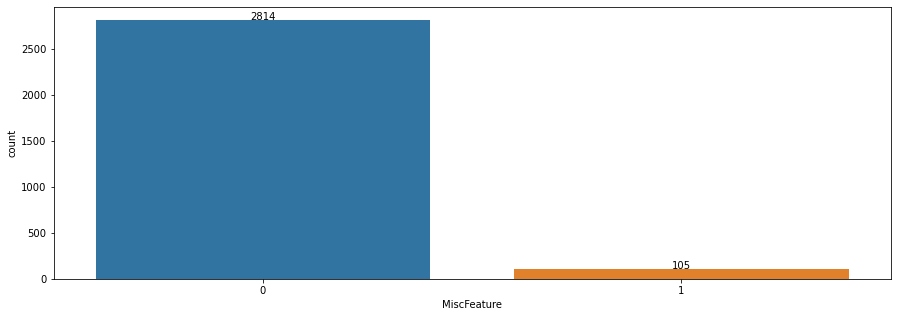

In [254]:

plt.figure(figsize=(15,5))
ax = sns.countplot(data['MiscFeature'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()


In [253]:
data['MiscFeature'] = data['MiscFeature'].map({
                                            'Gar2':1,
                                            'Othr':1,
                                            'Shed':1,
                                            'TenC':1,
                                                0:0
    
                                            
})

**MiscVal column**

In [256]:
print(data['MiscVal'].isnull().sum())
print(data['MiscVal'].nunique())

0
38


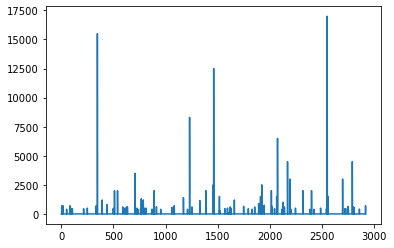

In [258]:
data['MiscVal'].plot()

In [259]:
print(skew(data['MiscVal']))
a = np.log1p(data['MiscVal'])
skew(a)

21.9471948077491


5.213983641404962

In [262]:
data['MiscVal'] = np.log1p(data['MiscVal'])
skew(data['MiscVal'])

5.213983641404962

SaleType column

In [267]:
print(data['SaleType'].isnull().sum())
print(data['SaleType'].nunique())

0
9


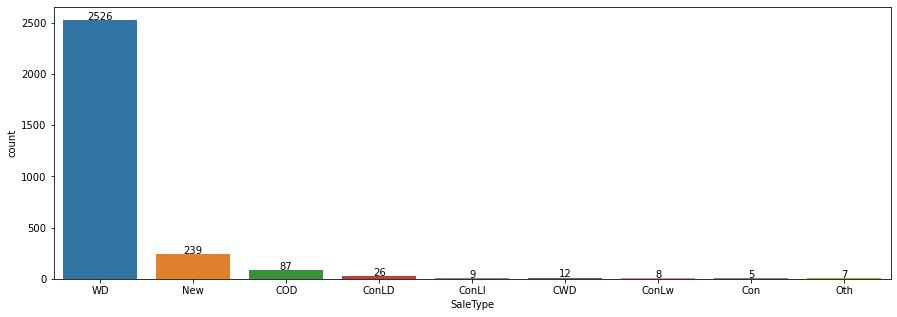

In [268]:

plt.figure(figsize=(15,5))
ax = sns.countplot(data['SaleType'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()


In [266]:
data['SaleType'].fillna('WD', inplace=True)

In [270]:
le = preprocessing.LabelEncoder()
data['SaleType'] = le.fit_transform(data['SaleType'])

**SaleCondtion column**

In [271]:
print(data['SaleCondition'].isnull().sum())
print(data['SaleCondition'].nunique())

0
6


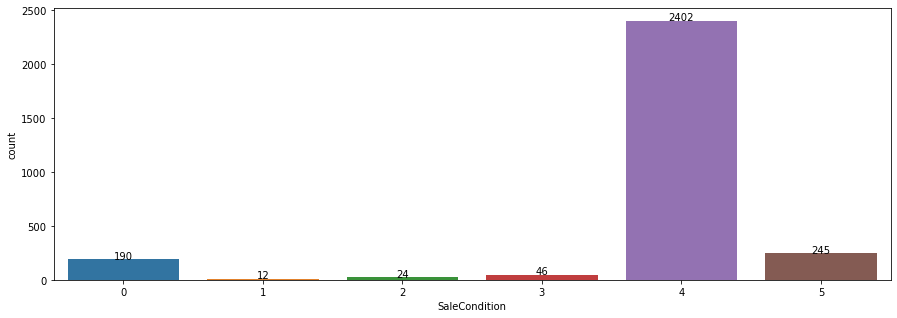

In [274]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['SaleCondition'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [273]:
le = preprocessing.LabelEncoder()
data['SaleCondition'] = le.fit_transform(data['SaleCondition'])

BsmtFullBath column

In [298]:
print(data['BsmtFullBath'].isnull().sum())
print(data['BsmtFullBath'].nunique())



0
4


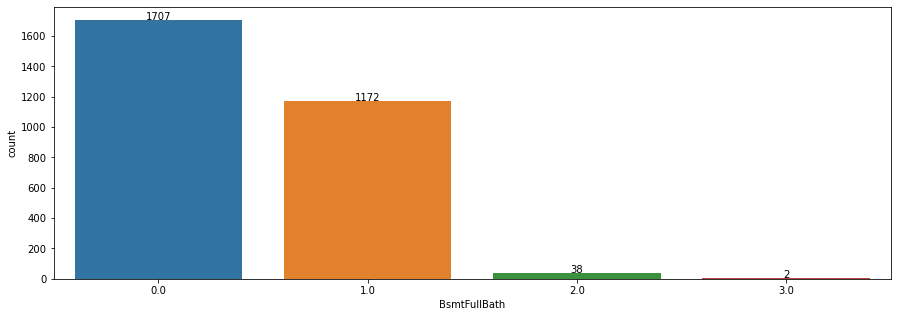

In [297]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['BsmtFullBath'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [296]:
data['BsmtFullBath'].fillna(0, inplace=True)

BsmtHalfBath column

In [299]:
print(data['BsmtHalfBath'].isnull().sum())
print(data['BsmtHalfBath'].nunique())



2
3


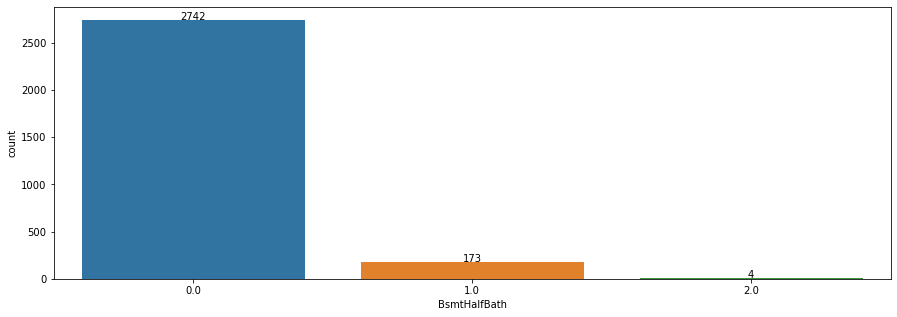

In [302]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['BsmtHalfBath'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [301]:
data['BsmtHalfBath'].fillna(1, inplace=True)

GarageCars column

In [307]:

print(data['GarageCars'].isnull().sum())
print(data['GarageCars'].nunique())



0
6


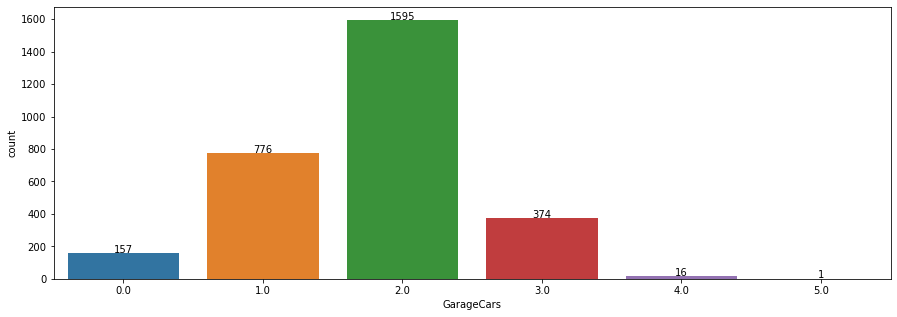

In [308]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data['GarageCars'])
for p in ax.patches:
    h = p.get_height()
    w = p.get_width()/2
    ax.text(p.get_x()+w, h+3,
            '{:1}'.format(h),
           ha="center")
plt.show()

In [306]:
data['GarageCars'].fillna(2, inplace=True)

# #Done with all columns not lets start with model building 

In [275]:
data

,Id,MSSubClass,LotFrontage,LotArea,Utilities,Neighborhood,Condition1,Condition2,HouseStyle,RoofStyle,...,Exter_quality,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,GarageFinish_0,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,Garage_Quality
0,1,5,65.0,9.042040,0,5,1,1,5,1,...,3,0,0,1,0,0,0,1,0,6
1,2,0,80.0,9.169623,0,24,2,1,2,1,...,2,0,0,0,1,0,0,1,0,6
2,3,5,68.0,9.328212,0,5,1,1,5,1,...,3,0,0,1,0,0,0,1,0,6
3,4,6,60.0,9.164401,0,6,1,1,5,1,...,2,0,0,1,0,0,0,0,1,6
4,5,5,84.0,9.565284,0,15,1,1,5,1,...,3,0,0,1,0,0,0,1,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,13,21.0,7.568896,0,10,1,1,5,1,...,2,0,0,0,1,1,0,0,0,0
2915,2916,13,21.0,7.546974,0,10,1,1,5,1,...,2,0,0,0,1,0,0,0,1,6
2916,2917,0,160.0,9.903538,0,11,1,1,2,1,...,2,0,0,0,1,0,0,0,1,6
2917,2918,9,62.0,9.253591,0,11,1,1,6,1,...,2,0,0,0,1,1,0,0,0,0


In [309]:
data.info()
  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 95 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  2919 non-null   int64  
 1   MSSubClass          2919 non-null   int64  
 2   LotFrontage         2919 non-null   float64
 3   LotArea             2919 non-null   float64
 4   Utilities           2919 non-null   int64  
 5   Neighborhood        2919 non-null   int64  
 6   Condition1          2919 non-null   int64  
 7   Condition2          2919 non-null   int64  
 8   HouseStyle          2919 non-null   int64  
 9   RoofStyle           2919 non-null   int64  
 10  RoofMatl            2919 non-null   int64  
 11  Exterior1st         2919 non-null   int64  
 12  Exterior2nd         2919 non-null   int64  
 13  MasVnrArea          2919 non-null   float64
 14  Foundation          2919 non-null   int64  
 15  BsmtQual            2919 non-null   int64  
 16  BsmtCo

In [312]:
train_data = data.iloc[:train.shape[0]]

In [314]:
train_data['SalePrice'].tail()

1455    175000.0
1456    210000.0
1457    266500.0
1458    142125.0
1459    147500.0
Name: SalePrice, dtype: float64

In [317]:
test_data = data.iloc[train.shape[0]:]
test_data['SalePrice'].head()

1460   NaN
1461   NaN
1462   NaN
1463   NaN
1464   NaN
Name: SalePrice, dtype: float64

**so we divided train and test data **

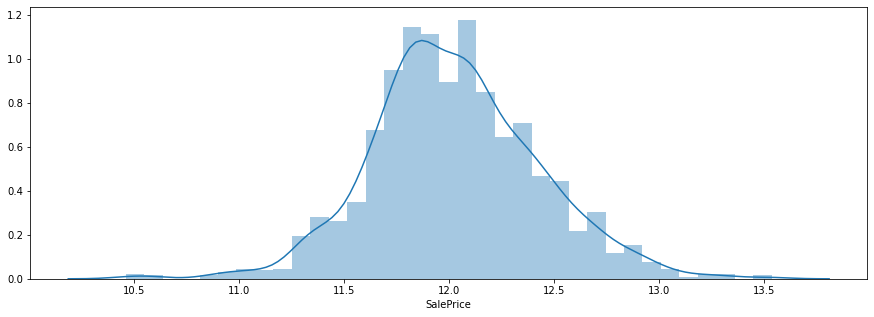

In [326]:
plt.figure(figsize=(15,5))
sns.distplot(train_data['SalePrice'])

In [324]:
print(skew(train_data['SalePrice']))
a = np.log1p(train_data['SalePrice'])
skew(a)

1.880940746034036


0.12122191311528363

In [325]:
train_data['SalePrice'] = np.log1p(train_data['SalePrice'])
skew(train_data['SalePrice'])

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


0.12122191311528363

In [327]:
train_data.to_csv('Train_data.csv' )
test_data.to_csv('Test_data.csv')

In [328]:
train_data

,Id,MSSubClass,LotFrontage,LotArea,Utilities,Neighborhood,Condition1,Condition2,HouseStyle,RoofStyle,...,Exter_quality,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,GarageFinish_0,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,Garage_Quality
0,1,5,65.0,9.042040,0,5,1,1,5,1,...,3,0,0,1,0,0,0,1,0,6
1,2,0,80.0,9.169623,0,24,2,1,2,1,...,2,0,0,0,1,0,0,1,0,6
2,3,5,68.0,9.328212,0,5,1,1,5,1,...,3,0,0,1,0,0,0,1,0,6
3,4,6,60.0,9.164401,0,6,1,1,5,1,...,2,0,0,1,0,0,0,0,1,6
4,5,5,84.0,9.565284,0,15,1,1,5,1,...,3,0,0,1,0,0,0,1,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,5,62.0,8.976894,0,8,1,1,5,1,...,2,0,0,0,1,0,0,1,0,6
1456,1457,0,85.0,9.486152,0,14,1,1,2,1,...,2,0,0,0,1,0,0,0,1,6
1457,1458,6,66.0,9.109746,0,6,1,1,5,1,...,6,0,0,1,0,0,0,1,0,6
1458,1459,0,68.0,9.181735,0,12,1,1,2,3,...,2,0,0,1,0,0,0,0,1,6


In [329]:

X=train_data.drop(['Id','SalePrice'],1)
y=train_data['SalePrice']
test_data=test_data.drop(['Id','SalePrice'],1)


In [406]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=7)


In [407]:
from xgboost import XGBRegressor
model_2 = XGBRegressor(
 learning_rate =0.01,
 n_estimators=5000,
 max_depth=10,
 gamma=0.1,
 colsample_bytree=0.8,
 seed=100,
 eval_metric='rmse'
 )
model_2.fit(X_train, y_train, eval_metric='rmse', 
          eval_set=[(X_test, y_test)], early_stopping_rounds=500, verbose=100)

[0]	validation_0-rmse:11.42839
Will train until validation_0-rmse hasn't improved in 500 rounds.
[100]	validation_0-rmse:4.20791
[200]	validation_0-rmse:1.56171
[300]	validation_0-rmse:0.59776
[400]	validation_0-rmse:0.26226
[500]	validation_0-rmse:0.16359
[600]	validation_0-rmse:0.14137
[700]	validation_0-rmse:0.13753
[800]	validation_0-rmse:0.13644
[900]	validation_0-rmse:0.13592
[1000]	validation_0-rmse:0.13567
[1100]	validation_0-rmse:0.13563
[1200]	validation_0-rmse:0.13535
[1300]	validation_0-rmse:0.13511
[1400]	validation_0-rmse:0.13503
[1500]	validation_0-rmse:0.13500
[1600]	validation_0-rmse:0.13495
[1700]	validation_0-rmse:0.13487
[1800]	validation_0-rmse:0.13487
[1900]	validation_0-rmse:0.13478
[2000]	validation_0-rmse:0.13471
[2100]	validation_0-rmse:0.13467
[2200]	validation_0-rmse:0.13467
[2300]	validation_0-rmse:0.13467
[2400]	validation_0-rmse:0.13468
[2500]	validation_0-rmse:0.13465
[2600]	validation_0-rmse:0.13458
[2700]	validation_0-rmse:0.13456
[2800]	validation_0-r

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=0.8, eval_metric='rmse',
             gamma=0.1, gpu_id=-1, importance_type='gain',
             interaction_constraints='', learning_rate=0.01, max_delta_step=0,
             max_depth=10, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=5000, n_jobs=0,
             num_parallel_tree=1, random_state=100, reg_alpha=0, reg_lambda=1,
             scale_pos_weight=1, seed=100, subsample=1, tree_method='exact',
             validate_parameters=1, verbosity=None)

In [408]:
xgb = XGBRegressor(
 learning_rate =0.01,
 n_estimators=3897,
 max_depth=10,
 gamma=0.1,
 colsample_bytree=0.8,
 seed=100,
 eval_metric='rmse'
 )

xgb_model=xgb.fit(X,y)

In [409]:
y_pred1=xgb.predict(test_data)

In [410]:
y_pred1=np.expm1(y_pred1)

In [411]:
y_pred1

array([121979.625, 157881.2  , 179192.06 , ..., 148435.17 , 120870.72 ,
       218513.6  ], dtype=float32)

let use LGBM AS WELL 

In [412]:
from lightgbm import LGBMRegressor
lgb_fit_params={"early_stopping_rounds":500, 
            "eval_metric" : 'rmse', 
            "eval_set" : [(X_test,y_test)],
            'eval_names': ['valid'],
            'verbose':100
           }

lgb_params = {'boosting_type': 'gbdt',
 'objective': 'regression',
 'metric': 'rmse',
 'verbose': 0,
 'bagging_fraction': 0.8,
 'bagging_freq': 1,
 'lambda_l1': 0.01,
 'lambda_l2': 0.01,
 'learning_rate': 0.001,
 'max_bin': 255,
 'max_depth': 9,
 'min_data_in_bin': 1,
 'min_data_in_leaf': 1,
 'num_leaves': 31}
lgb_params

{'boosting_type': 'gbdt',
 'objective': 'regression',
 'metric': 'rmse',
 'verbose': 0,
 'bagging_fraction': 0.8,
 'bagging_freq': 1,
 'lambda_l1': 0.01,
 'lambda_l2': 0.01,
 'learning_rate': 0.001,
 'max_bin': 255,
 'max_depth': 9,
 'min_data_in_bin': 1,
 'min_data_in_leaf': 1,
 'num_leaves': 31}

In [422]:
clf_lgb = LGBMRegressor(n_estimators=10000, **lgb_params, random_state=123456789, n_jobs=-1)
clf_lgb.fit(X_train, y_train, **lgb_fit_params)
clf_lgb.best_iteration_

Training until validation scores don't improve for 500 rounds
[100]	valid's rmse: 0.377417
[200]	valid's rmse: 0.351235
[300]	valid's rmse: 0.327938
[400]	valid's rmse: 0.306786
[500]	valid's rmse: 0.287559
[600]	valid's rmse: 0.270464
[700]	valid's rmse: 0.25493
[800]	valid's rmse: 0.241106
[900]	valid's rmse: 0.228688
[1000]	valid's rmse: 0.217652
[1100]	valid's rmse: 0.207737
[1200]	valid's rmse: 0.198884
[1300]	valid's rmse: 0.190951
[1400]	valid's rmse: 0.183887
[1500]	valid's rmse: 0.177704
[1600]	valid's rmse: 0.172258
[1700]	valid's rmse: 0.167398
[1800]	valid's rmse: 0.16313
[1900]	valid's rmse: 0.15938
[2000]	valid's rmse: 0.156036
[2100]	valid's rmse: 0.153008
[2200]	valid's rmse: 0.150408
[2300]	valid's rmse: 0.148063
[2400]	valid's rmse: 0.145998
[2500]	valid's rmse: 0.144144
[2600]	valid's rmse: 0.142475
[2700]	valid's rmse: 0.140942
[2800]	valid's rmse: 0.139578
[2900]	valid's rmse: 0.138394
[3000]	valid's rmse: 0.137292
[3100]	valid's rmse: 0.136329
[3200]	valid's rmse:

9984

In [423]:
clf_lgb=LGBMRegressor(n_estimators=int(clf_lgb.best_iteration_*1.2), **lgb_params)
lgb_model=clf_lgb.fit(X, y)


In [424]:
y_pred2=lgb_model.predict(test_data)

In [425]:
y_pred2=np.expm1(y_pred2)

In [426]:
y_pred2

array([122559.97800417, 162428.97380779, 182338.99477956, ...,
       143764.19515471, 114489.07154565, 215598.98356849])

**let us combine both model predictions**

In [427]:
y_pred=(0.6*y_pred1)+(y_pred2*0.4)
y_pred

array([122211.77245167, 159700.31608562, 180450.84009932, ...,
       146566.78743688, 118318.06611826, 217347.7496774 ])

In [379]:
sub.head()

,Id,SalePrice
0,1461,122618.189345
1,1462,160850.545205
2,1463,181758.578897
3,1464,184014.766864
4,1465,183538.827385


In [428]:
sub['SalePrice'] = y_pred

In [429]:
sub.to_csv('submission.csv')

In [397]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
ENet = make_pipeline(RobustScaler(), ElasticNet(alpha=0.0005, l1_ratio=.9, random_state=3))

In [398]:
n_folds = 5

def rmsle_cv(model):
    kf = KFold(n_folds, shuffle=True, random_state=42).get_n_splits(train.values)
    rmse= np.sqrt(-cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv = kf))
    return(rmse)

In [400]:
score = rmsle_cv(ENet)
print("\nLasso score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))


Lasso score: 0.1343 (0.0197)



In [402]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from math import sqrt 
from sklearn.metrics import mean_squared_error, mean_squared_log_error

errrf = []
y_pred_totrf = []

fold = KFold(n_splits=15, shuffle=True, random_state=42)

for train_index, test_index in fold.split(X):
    X_train, X_test = X.loc[train_index], X.loc[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    rf = RandomForestRegressor(random_state=42, n_estimators=200)
    rf.fit(X_train, y_train)

    y_pred_rf = rf.predict(X_test)
    print("RMSLE: ", sqrt(mean_squared_log_error(np.exp(y_test), np.exp(y_pred_rf))))

    errrf.append(sqrt(mean_squared_log_error(np.exp(y_test), np.exp(y_pred_rf))))
    p = rf.predict(test_data)
    y_pred_totrf.append(p)

RMSLE:  0.11785733369205427
RMSLE:  0.15905941242748292
RMSLE:  0.15442451060219434
RMSLE:  0.10235812337988541
RMSLE:  0.1495715873500391
RMSLE:  0.12404151255416926
RMSLE:  0.17550529602005804
RMSLE:  0.15042262288924085
RMSLE:  0.1534311493932451
RMSLE:  0.17503544743229557
RMSLE:  0.14980927050081783
RMSLE:  0.12799580942693964
RMSLE:  0.12173460174287101
RMSLE:  0.1272364921281828
RMSLE:  0.11355773612387111


In [403]:
final = np.exp(np.mean(y_pred_totrf,0))


In [404]:
sub['SalePrice'] = y_pred

In [405]:
sub.to_csv('submission.csv')